In [1]:
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 3, Finished, Available, Finished, False)

In [2]:
df_B = spark.read.format("delta").table("LH_UCL_Sales_Project.UCL_Sales.ucl_bookings")
display(df_B)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 4, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, baff5d50-8e4e-4651-b29e-99990fa69e7e)

In [3]:
df_F = spark.read.format("delta").table("LH_UCL_Sales_Project.UCL_Sales.ucl_flights")
display(df_F)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 5, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, f708bfe8-7f56-4457-bb3b-83918be5a06b)

In [4]:
df_B.printSchema()
df_F.printSchema()

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 6, Finished, Available, Finished, False)

root
 |-- Core_Flight_Offer_id: long (nullable = true)
 |-- Sales_Upper_Channel: string (nullable = true)
 |-- Upper_Channel_Sort: long (nullable = true)
 |-- POS_Country: string (nullable = true)
 |-- POS_SalesRegion: string (nullable = true)
 |-- Direct_Indirect: string (nullable = true)
 |-- Sales_Manager: string (nullable = true)
 |-- NDO_Range: string (nullable = true)
 |-- BucketID: long (nullable = true)
 |-- POC_Airport: string (nullable = true)
 |-- POC_Country: string (nullable = true)
 |-- OD: string (nullable = true)
 |-- DE_Feeder_YN: string (nullable = true)
 |-- DE_Defeeder_YN: string (nullable = true)
 |-- Compartment: string (nullable = true)
 |-- Bkd: long (nullable = true)
 |-- BkdRev_final: decimal(18,2) (nullable = true)

root
 |-- Core_Flight_Offer_id: long (nullable = true)
 |-- RT_Report_Season: string (nullable = true)
 |-- RT_Sort_Report_Season: double (nullable = true)
 |-- RT_Year_Month: string (nullable = true)
 |-- TourDest_KONT_IKONT_CITY: string (nullabl

In [5]:
df_B_P = df_B.toPandas()
df_F_P = df_F.toPandas()

print("Type of df_B_P:", type(df_B_P))
print("Type of df_F_P:", type(df_F_P))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 7, Finished, Available, Finished, False)

Type of df_B_P: <class 'pandas.core.frame.DataFrame'>
Type of df_F_P: <class 'pandas.core.frame.DataFrame'>


In [6]:
booking = df_B_P.copy()
flight  = df_F_P.copy()

print("\nType of booking DataFrame:", type(booking))
print("Type of flight DataFrame:",  type(flight))


StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 8, Finished, Available, Finished, False)


Type of booking DataFrame: <class 'pandas.core.frame.DataFrame'>
Type of flight DataFrame: <class 'pandas.core.frame.DataFrame'>


In [7]:
#Missing Value
def check_missing(df: pd.DataFrame, name: str) -> pd.DataFrame:
    miss = df.isnull().sum()
    miss = miss[miss > 0].sort_values(ascending=False)
    pct  = (miss / len(df) * 100).round(2)
    res  = pd.DataFrame({'missing_cnt': miss, 'missing_pct': pct})
    
    print(f"\n===== Missing Values: {name} =====")
    print(res)
    return res

check_missing(booking, "Booking")
check_missing(flight,  "Flight")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 9, Finished, Available, Finished, False)


===== Missing Values: Booking =====
                     missing_cnt  missing_pct
BkdRev_final                9376         0.11
Sales_Manager               7948         0.10
Sales_Upper_Channel          421         0.01
Direct_Indirect              421         0.01
POS_Country                   21         0.00
POS_SalesRegion               21         0.00
Upper_Channel_Sort             1         0.00
Bkd                            1         0.00

===== Missing Values: Flight =====
                          missing_cnt  missing_pct
Cap_C                          166476        71.26
Cap_P                           43213        18.50
TourDest_KONT_IKONT_CITY           94         0.04
TourDestination                    94         0.04
TourDest_Country                   94         0.04
TourDest_Airport                   94         0.04
TourDep_Airport                    12         0.01


,missing_cnt,missing_pct
Cap_C,166476,71.26
Cap_P,43213,18.50
TourDest_KONT_IKONT_CITY,94,0.04
TourDestination,94,0.04
TourDest_Country,94,0.04
TourDest_Airport,94,0.04
TourDep_Airport,12,0.01


In [8]:
# missingvalue clearing
# Booking 
booking['BkdRev_final'] = booking['BkdRev_final'].fillna(0)
booking = booking.dropna(subset=['Bkd'])

booking['Sales_Upper_Channel'] = booking['Sales_Upper_Channel'].fillna('Unknown')
booking['Direct_Indirect']     = booking['Direct_Indirect'].fillna('Unknown')
booking['Sales_Manager']       = booking['Sales_Manager'].fillna('Unknown')

booking['POS_Country']    = booking['POS_Country'].fillna('Unknown')
booking['POS_SalesRegion'] = booking['POS_SalesRegion'].fillna('Unknown')

booking['Upper_Channel_Sort'] = booking['Upper_Channel_Sort'].fillna(0)

# Flight 
flight['Cap_C'] = flight['Cap_C'].fillna(0)
flight['Cap_P'] = flight['Cap_P'].fillna(0)

tour_cols = [
    'TourDest_KONT_IKONT_CITY',
    'TourDestination',
    'TourDest_Country',
    'TourDest_Airport',
    'TourDep_Airport'
]
for col in tour_cols:
    flight[col] = flight[col].fillna('Unknown')

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 10, Finished, Available, Finished, False)

In [9]:
# check the basic value
print("\n===== Booking Data Info =====")
print("Shape (rows, columns):", booking.shape)
print("Column names:", list(booking.columns))
print("Data types:\n", booking.dtypes)

print("\n===== Flight Data Info =====")
print("Shape (rows, columns):", flight.shape)
print("Column names:", list(flight.columns))
print("Data types:\n", flight.dtypes)


StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 11, Finished, Available, Finished, False)


===== Booking Data Info =====
Shape (rows, columns): (8280336, 17)
Column names: ['Core_Flight_Offer_id', 'Sales_Upper_Channel', 'Upper_Channel_Sort', 'POS_Country', 'POS_SalesRegion', 'Direct_Indirect', 'Sales_Manager', 'NDO_Range', 'BucketID', 'POC_Airport', 'POC_Country', 'OD', 'DE_Feeder_YN', 'DE_Defeeder_YN', 'Compartment', 'Bkd', 'BkdRev_final']
Data types:
 Core_Flight_Offer_id      int64
Sales_Upper_Channel      object
Upper_Channel_Sort      float64
POS_Country              object
POS_SalesRegion          object
Direct_Indirect          object
Sales_Manager            object
NDO_Range                object
BucketID                  int64
POC_Airport              object
POC_Country              object
OD                       object
DE_Feeder_YN             object
DE_Defeeder_YN           object
Compartment              object
Bkd                     float64
BkdRev_final             object
dtype: object

===== Flight Data Info =====
Shape (rows, columns): (233620, 21)
Column n

In [10]:
# change data type
booking['BkdRev_final'] = pd.to_numeric(booking['BkdRev_final'], errors='coerce')
booking['Bkd']          = booking['Bkd'].astype(float)

print("\nBkdRev_final dtype:", booking['BkdRev_final'].dtype)
print("Bkd dtype:", booking['Bkd'].dtype)


StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 12, Finished, Available, Finished, False)


BkdRev_final dtype: float64
Bkd dtype: float64


In [11]:
# NDO Category
display("Unique NDO_Range values:")
display(pd.DataFrame(booking['NDO_Range'].unique(), columns=['NDO_Range']))

ndo_mapping = {
    'Dep Day':      'Late bookers',
    '1-7 days':     'Late bookers',
    '8-14 days':    'Late bookers',
    '15-30 days':   'Late bookers',
    '1-2 months':   'Late bookers',
    '2-3 months':   'Mid-term bookers',
    '3-6 months':   'Mid-term bookers',
    '>180 days':    'Early bookers'
}

booking['NDO_Category'] = booking['NDO_Range'].map(ndo_mapping)

display("\nNDO Range & Category Count:")
display(booking[['NDO_Range', 'NDO_Category']].value_counts().reset_index())

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 13, Finished, Available, Finished, False)

'Unique NDO_Range values:'

SynapseWidget(Synapse.DataFrame, 84e0e1f4-acca-4a67-aea3-4c7d609519ab)

'\nNDO Range & Category Count:'

SynapseWidget(Synapse.DataFrame, ebac8d32-fb0c-407e-8a8a-221b4cf64ff8)

In [12]:
# Combine the data
df_merged = pd.merge(
    booking,
    flight,
    on='Core_Flight_Offer_id',
    how='left',
    indicator='_merge_status'
)

display("\nMerge status count:")
display(df_merged['_merge_status'].value_counts())

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 14, Finished, Available, Finished, False)

'\nMerge status count:'

SynapseWidget(Synapse.DataFrame, 6935ef6d-c6f4-4b8b-b7b2-b414637c14c7)

In [13]:
unmatched_records = df_merged[df_merged['_merge_status'] == 'left_only'].copy()
display("\nUnmatched booking records:")
display(unmatched_records.head(10))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 15, Finished, Available, Finished, False)

'\nUnmatched booking records:'

SynapseWidget(Synapse.DataFrame, 742783bf-38ae-45f9-8ab8-4c790f734798)

In [14]:
df_final = df_merged[df_merged['_merge_status'] == 'both'].copy()
df_final = df_final.drop(columns=['_merge_status'])

print("\nFinal analysis dataset rows:", df_final.shape[0])

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 16, Finished, Available, Finished, False)


Final analysis dataset rows: 8280330


In [15]:
#Row Count Summary
display(pd.DataFrame({
    'Dataset': ['Original Booking Data', 'Matched Analysis Data', 'Unmatched Rows Removed'],
    'Row_Count': [df_merged.shape[0], df_final.shape[0], df_merged.shape[0] - df_final.shape[0]]
}))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 17, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 825779f2-7ae0-4b72-800b-923ee619b2b2)

In [16]:
display("Check duplicate flight IDs (should NOT explode)")
id_count = df_final['Core_Flight_Offer_id'].value_counts().head(10)
display(id_count)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 18, Finished, Available, Finished, False)

'Check duplicate flight IDs (should NOT explode)'

SynapseWidget(Synapse.DataFrame, f8528dbe-c981-4756-b6ed-e205f75c0a7d)

In [17]:
df_final = df_final[
    (df_final['Cap'] > 0) &
    (df_final['Bkd'] >= 0) &
    (df_final['BkdRev_final'] > 0)
].copy()

print("Rows after cleaning outliers:", df_final.shape[0])

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 19, Finished, Available, Finished, False)

Rows after cleaning outliers: 8251999


In [18]:
exclude_channel = ["Unknown", "NOT ALLOCATED"]
df_final = df_final[~df_final["Sales_Upper_Channel"].isin(exclude_channel)]

print("Final rows after channel filter:", df_final.shape[0])


StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 20, Finished, Available, Finished, False)

Final rows after channel filter: 8240177


# KPI

In [19]:
# 1. Season
df_final['Season_Type'] = df_final['RT_Report_Season'].apply(
    lambda x: 'Summer' if str(x).startswith('S') else 'Winter'
)

# 2. Channel Clean
df_final['Channel_Clean'] = df_final['Sales_Upper_Channel'].fillna('Unknown')

# 3. POS Clean
df_final['POS_Clean'] = df_final['POS_Country'].fillna('Unknown')

# 4. Sales Manager
df_final['Sales_Manager_Clean'] = df_final['Sales_Manager'].fillna('Unknown')

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 21, Finished, Available, Finished, False)

In [20]:
# KPI calculations
df_final['flight_cap'] = df_final.groupby('Core_Flight_Offer_id')['Cap'].transform('mean')
df_final['flight_total_bkd'] = df_final.groupby('Core_Flight_Offer_id')['Bkd'].transform('sum')

# SLF
df_final['flight_SLF'] = df_final['flight_total_bkd'] / df_final['flight_cap']
df_final['flight_SLF'] = df_final['flight_SLF'].clip(0, 1)

#  Yield
df_final['Yield'] = np.where(df_final['Bkd'] > 0, df_final['BkdRev_final'] / df_final['Bkd'], np.nan)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 22, Finished, Available, Finished, False)

In [21]:
# KPI RANGE check
print("===== KPI RANGE CHECK =====")
print(f"SLF range: {df_final['flight_SLF'].min():.2f} ~ {df_final['flight_SLF'].max():.2f}")
print(f"Yield range: {df_final['Yield'].min():.2f} ~ {df_final['Yield'].max():.2f}\n")


StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 23, Finished, Available, Finished, False)

===== KPI RANGE CHECK =====
SLF range: 0.00 ~ 1.00
Yield range: 0.00 ~ 46369.58



In [22]:
# dimansion KPI FUnction
def calculate_channel_kpis(df, group_columns):
    df_analysis = df.copy()
    kpi_table = df_analysis.groupby(group_columns, as_index=False, dropna=False).agg(
        Sum_Bkd=("Bkd", "sum"),
        Sum_Revenue=("BkdRev_final", "sum"),
        Sum_Cap=("Cap", "sum")
    )

    kpi_table["SLF"] = kpi_table["Sum_Bkd"] / kpi_table["Sum_Cap"]
    kpi_table["SLF"] = kpi_table["SLF"].clip(0, 1)

    kpi_table["Yield"] = np.where(
        kpi_table["Sum_Bkd"] > 0,
        kpi_table["Sum_Revenue"] / kpi_table["Sum_Bkd"],
        np.nan
    )

    kpi_table["Yield"] = kpi_table["Yield"].round(2)
    kpi_table["SLF"] = kpi_table["SLF"].round(3)

    return kpi_table

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 24, Finished, Available, Finished, False)

In [23]:
drill_4dim = calculate_channel_kpis(
    df_final,
    [
        'Sales_Upper_Channel', 'RT_Report_Season', 'POS_Country', 'NDO_Range',
        'Sales_Manager_Clean', 'TourDestination', 'NDO_Category', 'Compartment',
        'POS_SalesRegion', 'DE_Feeder_YN', 'POC_Country', 'OD', 'Core_Flight_Offer_id',"RT_Year_Month"
    ]
)

print("\n===== 4-Dimension Drill Down (Required) =====")
display(drill_4dim)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 25, Finished, Available, Finished, False)


===== 4-Dimension Drill Down (Required) =====


SynapseWidget(Synapse.DataFrame, dc32e5f4-a7e0-4b72-8fe8-f3fcd6039f6c)

In [24]:
df = drill_4dim.copy()
s = df['RT_Report_Season'].astype(str).str.strip().str.upper()

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 26, Finished, Available, Finished, False)

In [25]:
df['Season_Type'] = np.select(
    condlist=[s.str.startswith('S'), s.str.startswith('W')],
    choicelist=['Summer', 'Winter'],
    default='Unknown'
)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 27, Finished, Available, Finished, False)

In [26]:
df['Year'] = np.nan

summer_mask = df['Season_Type'] == 'Summer'
df.loc[summer_mask, 'Year'] = df.loc[summer_mask, 'RT_Report_Season'].str[1:3].astype('Int64')

winter_mask = df['Season_Type'] == 'Winter'
df.loc[winter_mask, 'Year'] = df.loc[winter_mask, 'RT_Report_Season'].str[1:3].astype('Int64')

df['Year'] = df['Year'].fillna(99).astype(int)

df.loc[summer_mask, 'TBY'] = 'TBY' + (df.loc[summer_mask, 'Year'] - 1).astype(str) + '/' + df.loc[summer_mask, 'Year'].astype(str)
df.loc[winter_mask, 'TBY'] = 'TBY' + df.loc[winter_mask, 'RT_Report_Season'].str[1:3] + '/' + df.loc[winter_mask, 'RT_Report_Season'].str[3:5]

df['TBY'] = df['TBY'].fillna('Unknown')

tby_mapping = {
    "TBY22/23": "TBY22/23",
    "TBY23/24": "TBY23/24",
    "TBY24/25": "TBY24/25",
    "TBY25/26": "TBY25/26 (partial)"
}
df['TBY'] = df['TBY'].map(tby_mapping).fillna(df['TBY'])


StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 28, Finished, Available, Finished, False)

In [27]:
final_columns = [
    'TBY', 'Year', 'Season_Type', 'RT_Report_Season',
    'Sales_Upper_Channel', 'POS_Country', 'TourDestination', 'NDO_Range', 'NDO_Category',
    'Sales_Manager_Clean', 'Sum_Bkd', 'Sum_Revenue', 'Sum_Cap',
    'SLF', 'Yield',
    'Compartment', 'POS_SalesRegion', 'DE_Feeder_YN', 'POC_Country',"RT_Year_Month",
    'Core_Flight_Offer_id', 'OD'
]

drill_4dim_final = df[final_columns]

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 29, Finished, Available, Finished, False)

In [28]:
# excep 2026
FULL_YEARS = ['TBY22/23', 'TBY23/24', 'TBY24/25']
drill_4dim_final_no2026 = drill_4dim_final[drill_4dim_final['TBY'].isin(FULL_YEARS)].copy()

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 30, Finished, Available, Finished, False)

In [29]:
# display the result
print("\n===== 4-DIM DRILL DOWN + SEASON + YEAR + TBY (FINAL) =====")
display(drill_4dim_final.head(200))

print("\n===== Final Dataset (Only Full TBY: 22/23, 23/24, 24/25) =====")
display(drill_4dim_final_no2026)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 31, Finished, Available, Finished, False)


===== 4-DIM DRILL DOWN + SEASON + YEAR + TBY (FINAL) =====


SynapseWidget(Synapse.DataFrame, d11ad613-6beb-4c8d-a00d-560e2a6b77cf)


===== Final Dataset (Only Full TBY: 22/23, 23/24, 24/25) =====


SynapseWidget(Synapse.DataFrame, e1de7345-67ec-49f4-97a1-5bea99fdccd8)

# 4.1 Changes in Channel structure 

## 4.1.0 Basic data preparation

In [30]:
total_by_tby = drill_4dim_final.groupby(['TBY', 'Season_Type'], as_index=False).agg(
    Total_Bkd=('Sum_Bkd', 'sum'),
    Total_Revenue=('Sum_Revenue', 'sum')
)

channel_tby = drill_4dim_final.groupby(
    ['TBY', 'Year', 'Season_Type', 'Sales_Upper_Channel'], as_index=False
).agg(Bkd=('Sum_Bkd', 'sum'), Revenue=('Sum_Revenue', 'sum'))

channel_tby = channel_tby.merge(total_by_tby, on=['TBY', 'Season_Type'], how='left')
channel_tby['Bkd_Share'] = channel_tby['Bkd'] / channel_tby['Total_Bkd']
channel_tby['Revenue_Share'] = channel_tby['Revenue'] / channel_tby['Total_Revenue']

# check TBY25/26 Winter is cover 2026-04
winter2526_check = drill_4dim_final[
    (drill_4dim_final['TBY'] == 'TBY25/26 (partial)') & (drill_4dim_final['Season_Type'] == 'Winter')
].groupby('RT_Year_Month', as_index=False).agg(Bkd=('Sum_Bkd', 'sum')).sort_values('RT_Year_Month')
print("Winter25/26 cover 2026-04:")
display(winter2526_check)

# 3 complete year + TBY25/26 Winter
KEEP_MASK = (
    channel_tby['TBY'].isin(['TBY22/23', 'TBY23/24', 'TBY24/25'])
    | ((channel_tby['TBY'] == 'TBY25/26 (partial)') & (channel_tby['Season_Type'] == 'Winter'))
)
channel_tby = channel_tby[KEEP_MASK].copy()

print("\nchannel_tby cover range:")
display(channel_tby[['TBY', 'Season_Type']].drop_duplicates().sort_values(['TBY', 'Season_Type']))

check = channel_tby.groupby(['TBY', 'Season_Type'])[['Bkd_Share', 'Revenue_Share']].sum()
print("\n share nearly equal to 1.0):")
display(check)

# Phase rules
def get_phase(tby, season_type):
    if tby in ['TBY22/23', 'TBY23/24']:
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Winter':
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Summer':
        return 'Post'
    elif tby == 'TBY25/26 (partial)' and season_type == 'Winter':
        return 'Post'
    else:
        return None

channel_tby['Phase'] = channel_tby.apply(
    lambda row: get_phase(row['TBY'], row['Season_Type']), axis=1
)
display(channel_tby[['TBY', 'Season_Type', 'Phase']].drop_duplicates().sort_values(['TBY', 'Season_Type']))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 32, Finished, Available, Finished, False)

Winter25/26 cover 2026-04:


SynapseWidget(Synapse.DataFrame, cbaeec35-3a70-4900-a0fb-74b2fae05635)


channel_tby cover range:


SynapseWidget(Synapse.DataFrame, 9a64bab3-532f-4f90-b468-5e2bf0194452)


 share nearly equal to 1.0):


SynapseWidget(Synapse.DataFrame, fcd4a4cb-2202-436e-b534-066b966a86c4)

SynapseWidget(Synapse.DataFrame, 0968c2d8-a4ef-4990-8c18-85795446601c)

In [31]:
# 4.1.1 Nine Channels -> Three Major Categories Mapping, Aggregated Share Table (Including Phase)

channel_tby['_channel_normalized'] = channel_tby['Sales_Upper_Channel'].str.strip().str.upper()

channel_map = {
    'WEB': 'Direct', 'DIRECT SALES': 'Direct',
    'TRAVEL AGENTS': 'Agent', 'OTA': 'Agent', 'CORPORATE': 'Agent',
    'ALLOTMENT PARTNER': 'Wholesale', 'TO': 'Wholesale', 'CONSOLIDATOR': 'Wholesale',
}
channel_tby['Channel_Category'] = channel_tby['_channel_normalized'].map(channel_map)

unmapped = channel_tby[channel_tby['Channel_Category'].isna()]['Sales_Upper_Channel'].unique()
print("\nUnmapped channels (expected to be only OAL):", unmapped)

category_tby = channel_tby[channel_tby['Channel_Category'].notna()].groupby(
    ['TBY', 'Year', 'Season_Type', 'Channel_Category'], as_index=False
).agg(
    Bkd=('Bkd', 'sum'),
    Revenue=('Revenue', 'sum'),
    Total_Bkd=('Total_Bkd', 'first'),
    Total_Revenue=('Total_Revenue', 'first'),
    Phase=('Phase', 'first')
)
category_tby['Bkd_Share'] = category_tby['Bkd'] / category_tby['Total_Bkd']
category_tby['Revenue_Share'] = category_tby['Revenue'] / category_tby['Total_Revenue']

share_table_bkd = category_tby.pivot_table(
    index=['TBY', 'Year', 'Season_Type'], columns='Channel_Category', values='Bkd_Share'
).reindex(columns=['Direct', 'Agent', 'Wholesale']).round(4).reset_index()

share_table_rev = category_tby.pivot_table(
    index=['TBY', 'Year', 'Season_Type'], columns='Channel_Category', values='Revenue_Share'
).reindex(columns=['Direct', 'Agent', 'Wholesale']).round(4).reset_index()

print("\nBooking volume share comparison table for three major categories (including TBY25/26 partial Winter):")
display(share_table_bkd)
print("\nRevenue share comparison table for three major categories (including TBY25/26 partial Winter):")
display(share_table_rev)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 33, Finished, Available, Finished, False)


Unmapped channels (expected to be only OAL): ['OAL']

Booking volume share comparison table for three major categories (including TBY25/26 partial Winter):


SynapseWidget(Synapse.DataFrame, 1208af76-92ca-4e9e-bc1f-43ad53864645)


Revenue share comparison table for three major categories (including TBY25/26 partial Winter):


SynapseWidget(Synapse.DataFrame, c451b98b-455f-4b42-ac90-56f1e7b28375)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 34, Finished, Available, Finished, False)

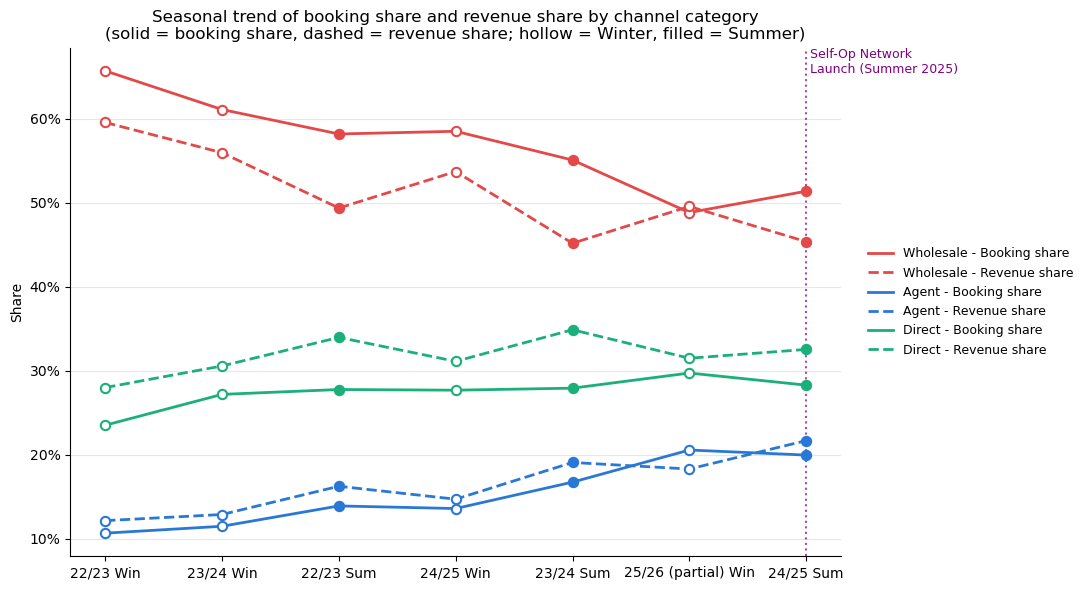

In [32]:
# 4.1.1 (Chart) Seasonal trend of booking share and revenue share by category
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
 
# Merge booking share and revenue share tables, aligned on TBY + Season
plot_df = share_table_bkd.merge(
    share_table_rev, on=['TBY', 'Year', 'Season_Type'], suffixes=('_Bkd', '_Rev')
).sort_values(['Year', 'Season_Type'], ascending=[True, False])  # Winter before Summer within each year
 
# x-axis labels, e.g. "22/23 Win"
season_label = {'Winter': 'Win', 'Summer': 'Sum'}
plot_df['x_label'] = plot_df['TBY'].str.replace('TBY', '') + ' ' + plot_df['Season_Type'].map(season_label)
x = range(len(plot_df))
 
categories = ['Wholesale', 'Agent', 'Direct']
colors = {'Wholesale': '#e34948', 'Agent': '#2a78d6', 'Direct': '#1baf7a'}
 
fig, ax = plt.subplots(figsize=(11, 6))
 
for cat in categories:
    # Booking share: solid line
    ax.plot(x, plot_df[f'{cat}_Bkd'], color=colors[cat], linewidth=2,
             linestyle='-', label=f'{cat} - Booking share', zorder=3)
    # Revenue share: dashed line
    ax.plot(x, plot_df[f'{cat}_Rev'], color=colors[cat], linewidth=2,
             linestyle='--', label=f'{cat} - Revenue share', zorder=3)
 
    # Hollow markers for Winter, filled markers for Summer (applied to both series)
    for col in [f'{cat}_Bkd', f'{cat}_Rev']:
        for i, season in enumerate(plot_df['Season_Type']):
            face = 'white' if season == 'Winter' else colors[cat]
            ax.scatter(i, plot_df[col].iloc[i], s=45, facecolor=face,
                       edgecolor=colors[cat], linewidth=1.5, zorder=4)
 
# Transition-event marker line (Summer 2025, i.e. TBY24/25 Summer -> "24/25 Sum")
launch_idx = plot_df[plot_df['x_label'] == '24/25 Sum'].index
if len(launch_idx) > 0:
    launch_pos = list(plot_df.index).index(launch_idx[0])
    ax.axvline(x=launch_pos, color='purple', linestyle=':', linewidth=1.5, alpha=0.7)
    ax.text(launch_pos, ax.get_ylim()[1] if ax.get_ylim()[1] else 0.7,
            ' Self-Op Network\n Launch (Summer 2025)', color='purple', fontsize=9, va='top')
 
ax.set_xticks(list(x))
ax.set_xticklabels(plot_df['x_label'], rotation=0)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_ylabel('Share')
ax.set_title('Seasonal trend of booking share and revenue share by channel category\n'
             '(solid = booking share, dashed = revenue share; hollow = Winter, filled = Summer)',
             fontsize=12)
ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
 
# Legend placed outside the plot area, right side, to avoid overlapping the lines
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, frameon=False)
 
plt.tight_layout()
plt.savefig('Figure_4.0_Seasonal_Trend_by_Category.png', dpi=300, bbox_inches='tight')
plt.show()
 

In [33]:
#  4.1.2 Nine-Channel Share Comparison Table (Year x Season x Channel, Including TBY25/26 Partial Winter) 

share_table_bkd = channel_tby.pivot_table(
    index=['TBY', 'Year', 'Season_Type'], columns='Sales_Upper_Channel',
    values='Bkd_Share'
).round(4).reset_index()

share_table_rev = channel_tby.pivot_table(
    index=['TBY', 'Year', 'Season_Type'], columns='Sales_Upper_Channel',
    values='Revenue_Share'
).round(4).reset_index()

print("Nine-channel booking volume share comparison table (data completeness for the last row, TBY25/26 Winter, to be confirmed):")
display(share_table_bkd)
print("\nNine-channel revenue share comparison table (data completeness for the last row, TBY25/26 Winter, to be confirmed):")
display(share_table_rev)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 35, Finished, Available, Finished, False)

Nine-channel booking volume share comparison table (data completeness for the last row, TBY25/26 Winter, to be confirmed):


SynapseWidget(Synapse.DataFrame, 2e787ed6-21b1-4103-8dce-c4452655be10)


Nine-channel revenue share comparison table (data completeness for the last row, TBY25/26 Winter, to be confirmed):


SynapseWidget(Synapse.DataFrame, 6b38833f-a699-418a-a194-5a4b70e8b04d)

# 渠道份额变化趋势图(九渠道) 

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 36, Finished, Available, Finished, False)

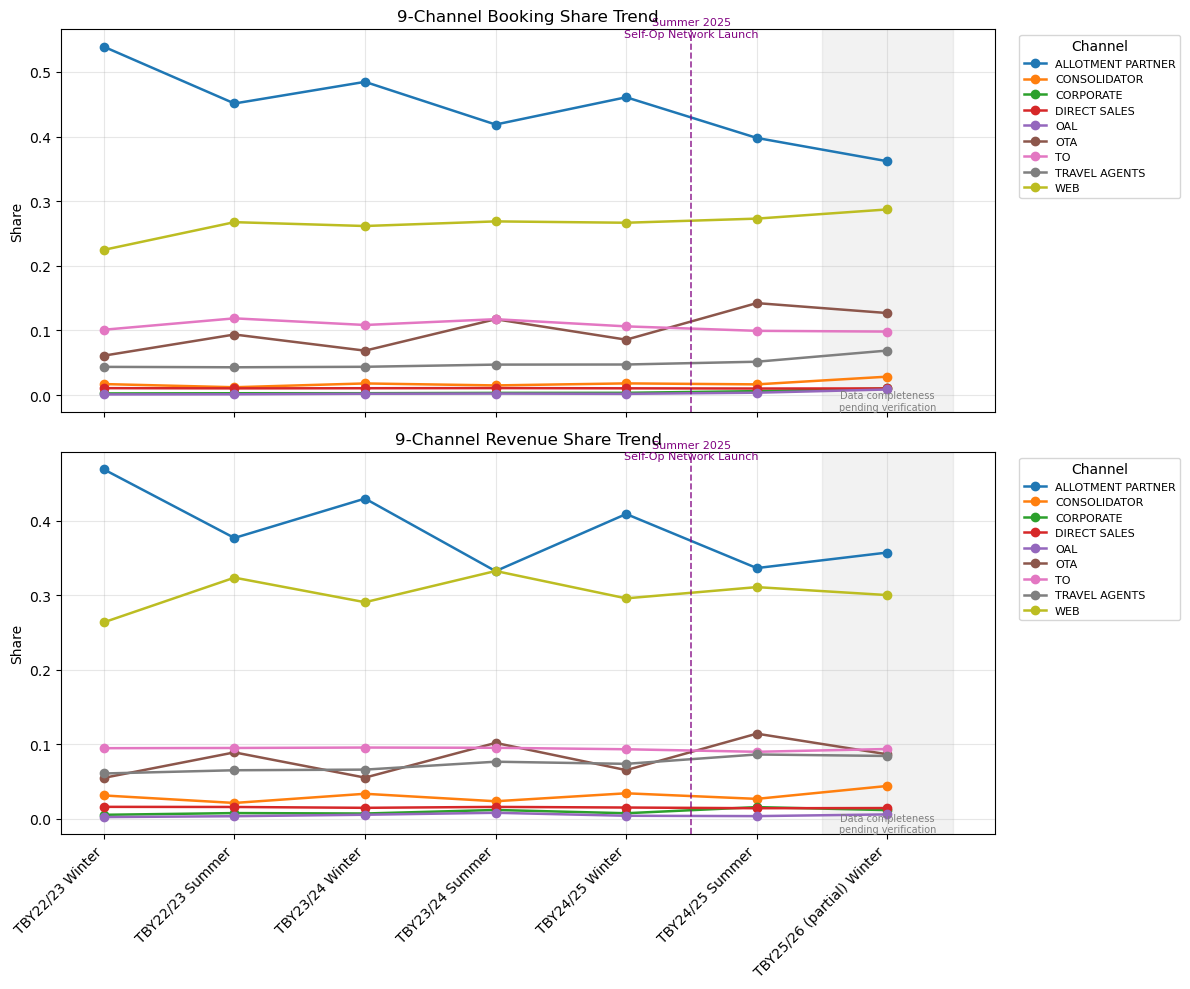

In [34]:
# ===== 4.1.2 Trend Chart (Line Plot, 9 Channels, with Self-Op Launch Breakpoint) =====
season_order = {'Winter': 0, 'Summer': 1}
channel_tby['Season_Order'] = channel_tby['Season_Type'].map(season_order)
channel_tby = channel_tby.sort_values(['TBY', 'Season_Order'])
channel_tby['Period'] = channel_tby['TBY'] + ' ' + channel_tby['Season_Type']
period_order = channel_tby[['Period']].drop_duplicates()['Period'].tolist()

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

channels_9 = sorted(channel_tby['Sales_Upper_Channel'].unique())
cmap = plt.get_cmap('tab10')
colors = {ch: cmap(i) for i, ch in enumerate(channels_9)}

for ax, value_col, title in zip(
    axes, ['Bkd_Share', 'Revenue_Share'],
    ['9-Channel Booking Share Trend', '9-Channel Revenue Share Trend']
):
    for ch in channels_9:
        sub = channel_tby[channel_tby['Sales_Upper_Channel'] == ch].set_index('Period').reindex(period_order)
        ax.plot(period_order, sub[value_col], marker='o', linewidth=1.8, label=ch, color=colors[ch])

    # Mark Self-Op Network Launch breakpoint (Summer 2025)
    winter2425_idx = period_order.index('TBY24/25 Winter')
    ax.axvline(winter2425_idx + 0.5, color='purple', linestyle='--', linewidth=1.2, alpha=0.8)
    ax.text(winter2425_idx + 0.5, ax.get_ylim()[1]*0.98, 'Summer 2025\nSelf-Op Network Launch', color='purple', fontsize=8, ha='center')

    last_idx = len(period_order) - 1
    ax.axvspan(last_idx - 0.5, last_idx + 0.5, color='gray', alpha=0.1)
    ax.text(last_idx, ax.get_ylim()[0], 'Data completeness\npending verification',
            color='gray', fontsize=7, ha='center', va='bottom')

    ax.set_title(title)
    ax.set_ylabel('Share')
    ax.legend(title='Channel', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
    ax.grid(alpha=0.3)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [35]:
# 4.1.3 Seasonal Matching Comparison: Whether 2025 Deviates from the Baseline Period's Same-Season Fluctuation Range (Nine Channels) 

def get_phase(tby, season_type):
    if tby in ['TBY22/23', 'TBY23/24']:
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Winter':
        return 'Baseline'  
    elif tby == 'TBY24/25' and season_type == 'Summer':
        return 'Post'
    elif tby == 'TBY25/26 (partial)' and season_type == 'Winter':
        return 'Post'
    else:
        return None  

channel_tby['Phase'] = channel_tby.apply(
    lambda row: get_phase(row['TBY'], row['Season_Type']), axis=1
)

def season_matched_comparison(value_col):
    records = []
    for ch in channel_tby['Sales_Upper_Channel'].unique():
        for season in ['Summer', 'Winter']:
            sub = channel_tby[
                (channel_tby['Sales_Upper_Channel'] == ch) & (channel_tby['Season_Type'] == season)
            ].sort_values('TBY')  

            baseline = sub[sub['Phase'] == 'Baseline']
            post = sub[sub['Phase'] == 'Post']

            if len(baseline) < 2 or len(post) < 1:
                records.append({
                    'Sales_Upper_Channel': ch, 'Season_Type': season,
                    'Baseline_Periods': ', '.join(baseline['TBY'].tolist()) if len(baseline) > 0 else 'N/A',
                    'Baseline_Mean': np.nan, 'Baseline_Std': np.nan,
                    'Post_Period': ', '.join(post['TBY'].tolist()) if len(post) > 0 else 'N/A',
                    'Post_Value': np.nan, 'Deviation': np.nan, 'Outside_Baseline_1SD': np.nan,
                    'Note': 'Insufficient baseline or post data for this season'
                })
                continue

            baseline_mean = baseline[value_col].mean()
            baseline_std = baseline[value_col].std()
            post_mean = post[value_col].mean()
            deviation = post_mean - baseline_mean
            outside_1std = abs(deviation) > baseline_std if baseline_std > 0 else np.nan

            note = ''
            if season == 'Winter' and 'TBY25/26 (partial)' in post['TBY'].tolist():
                note = 'Post period uses TBY25/26 (partial) - data completeness pending verification'

            records.append({
                'Sales_Upper_Channel': ch, 'Season_Type': season,
                'Baseline_Periods': ', '.join(baseline['TBY'].tolist()),
                'Baseline_Mean': round(baseline_mean, 4), 'Baseline_Std': round(baseline_std, 4),
                'Post_Period': ', '.join(post['TBY'].tolist()),
                'Post_Value': round(post_mean, 4),
                'Deviation': round(deviation, 4), 'Outside_Baseline_1SD': outside_1std,
                'Note': note
            })
    return pd.DataFrame(records)

season_match_bkd = season_matched_comparison('Bkd_Share')
season_match_rev = season_matched_comparison('Revenue_Share')
print("Seasonal matching comparison table (booking volume share, nine channels):")
display(season_match_bkd)
print("\nSeasonal matching comparison table (revenue share, nine channels):")
display(season_match_rev)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 37, Finished, Available, Finished, False)

Seasonal matching comparison table (booking volume share, nine channels):


SynapseWidget(Synapse.DataFrame, f9dad3d9-4671-4522-9ada-83810c798539)


Seasonal matching comparison table (revenue share, nine channels):


SynapseWidget(Synapse.DataFrame, af93ec6d-b209-4a36-bc97-a5d474946590)

In [36]:
# 4.1.4:Baseline/Post
def get_phase(tby, season_type):
    if tby in ['TBY22/23', 'TBY23/24']:
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Winter':
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Summer':
        return 'Post'
    elif tby == 'TBY25/26 (partial)' and season_type == 'Winter':
        return 'Post'
    else:
        return None

channel_tby_ss = channel_tby.copy()
channel_tby_ss['Phase'] = channel_tby_ss.apply(
    lambda row: get_phase(row['TBY'], row['Season_Type']), axis=1
)

def run_shift_share(season_filter):
    """
    Perform shift-share decomposition for a single season (Summer or Winter).
    Both Baseline and Post only include observations for that season, and all values
    are converted to a "per-period average" basis, to avoid artificial effects caused
    by inconsistent number of periods covered between Baseline and Post.
    """
    sub = channel_tby_ss[channel_tby_ss['Season_Type'] == season_filter].copy()

    baseline_tbys = sub[sub['Phase'] == 'Baseline']['TBY'].unique()
    post_tbys = sub[sub['Phase'] == 'Post']['TBY'].unique()

    if len(baseline_tbys) == 0 or len(post_tbys) == 0:
        print(f"\n{season_filter}: No data in Baseline or Post period, skipping")
        return None

    n_baseline = len(baseline_tbys)
    n_post = len(post_tbys)

    #  Booking volume per channel: sum by channel first, then divide by number of periods to get "per-period average" 
    baseline_ss = sub[sub['Phase'] == 'Baseline'].groupby(
        'Sales_Upper_Channel', as_index=False
    ).agg(Bkd_0=('Bkd', 'sum'), Total_Bkd_0=('Total_Bkd', 'sum'))
    baseline_ss['Bkd_0'] = baseline_ss['Bkd_0'] / n_baseline

    post_ss = sub[sub['Phase'] == 'Post'].groupby(
        'Sales_Upper_Channel', as_index=False
    ).agg(Bkd_1=('Bkd', 'sum'), Total_Bkd_1=('Total_Bkd', 'sum'))
    post_ss['Bkd_1'] = post_ss['Bkd_1'] / n_post

    shift_share = baseline_ss.merge(post_ss, on='Sales_Upper_Channel')

    # Check whether totals are consistent (this checks the raw summed values, unaffected by the per-period average processing)
    n_unique_0 = shift_share['Total_Bkd_0'].nunique()
    n_unique_1 = shift_share['Total_Bkd_1'].nunique()
    print(f"\n===== {season_filter} Validation =====")
    print(f"Number of unique Total_Bkd_0 values: {n_unique_0} (should be 1)")
    print(f"Number of unique Total_Bkd_1 values: {n_unique_1} (should be 1)")
    print(f"TBYs covered by Baseline ({season_filter}, n={n_baseline}): {baseline_tbys}")
    print(f"TBYs covered by Post ({season_filter}, n={n_post}): {post_tbys}")

    #  Total: also converted to "per-period average" basis, then calculate growth rate 
    baseline_total_sum = total_by_tby[
        (total_by_tby['TBY'].isin(baseline_tbys)) & (total_by_tby['Season_Type'] == season_filter)
    ]['Total_Bkd'].drop_duplicates().sum()
    baseline_total = baseline_total_sum / n_baseline

    post_total_sum = total_by_tby[
        (total_by_tby['TBY'].isin(post_tbys)) & (total_by_tby['Season_Type'] == season_filter)
    ]['Total_Bkd'].drop_duplicates().sum()
    post_total = post_total_sum / n_post

    total_growth_rate = (post_total - baseline_total) / baseline_total
    print(f"Total growth rate ({season_filter}, per-period average basis): {total_growth_rate:.4f}")
    print(f"  (Baseline per-period average: {baseline_total:.1f}, Post per-period average: {post_total:.1f})")

    #  Shift-Share decomposition: all based on per-period averages 
    shift_share['Total_Effect'] = shift_share['Bkd_0'] * total_growth_rate
    shift_share['Actual_Change'] = shift_share['Bkd_1'] - shift_share['Bkd_0']
    shift_share['Structural_Effect'] = shift_share['Actual_Change'] - shift_share['Total_Effect']
    shift_share['Season_Type'] = season_filter

    print(f"\nShift-Share decomposition results ({season_filter}, per-period average basis):")
    display(shift_share[['Sales_Upper_Channel', 'Actual_Change', 'Total_Effect', 'Structural_Effect']].round(1))

    return shift_share

# Run Summer and Winter separately
shift_share_summer = run_shift_share('Summer')
shift_share_winter = run_shift_share('Winter')

# Combine into a single comparison table for easy side-by-side comparison of each channel's performance across the two seasons
if shift_share_summer is not None and shift_share_winter is not None:
    shift_share_combined = pd.concat([shift_share_summer, shift_share_winter], ignore_index=True)
    comparison = shift_share_combined.pivot_table(
        index='Sales_Upper_Channel', columns='Season_Type',
        values=['Actual_Change', 'Total_Effect', 'Structural_Effect']
    ).round(1)

    comparison = comparison.reset_index()
    comparison.columns = ['_'.join(col).strip('_') if isinstance(col, tuple) else col for col in comparison.columns]

    print("\n===== Summer vs Winter Structural Effect Comparison Table (per-period average basis, includes channel name column) =====")
    display(comparison)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 38, Finished, Available, Finished, False)


===== Summer Validation =====
Number of unique Total_Bkd_0 values: 1 (should be 1)
Number of unique Total_Bkd_1 values: 1 (should be 1)
TBYs covered by Baseline (Summer, n=2): ['TBY22/23' 'TBY23/24']
TBYs covered by Post (Summer, n=1): ['TBY24/25']
Total growth rate (Summer, per-period average basis): 0.1279
  (Baseline per-period average: 6855847.5, Post per-period average: 7732841.0)

Shift-Share decomposition results (Summer, per-period average basis):


SynapseWidget(Synapse.DataFrame, 66730885-20f7-4c33-a208-f66882677508)


===== Winter Validation =====
Number of unique Total_Bkd_0 values: 1 (should be 1)
Number of unique Total_Bkd_1 values: 1 (should be 1)
TBYs covered by Baseline (Winter, n=3): ['TBY22/23' 'TBY23/24' 'TBY24/25']
TBYs covered by Post (Winter, n=1): ['TBY25/26 (partial)']
Total growth rate (Winter, per-period average basis): 0.3327
  (Baseline per-period average: 2928827.3, Post per-period average: 3903306.0)

Shift-Share decomposition results (Winter, per-period average basis):


SynapseWidget(Synapse.DataFrame, 81b899e5-ae11-414c-a67e-ee28c67f3120)


===== Summer vs Winter Structural Effect Comparison Table (per-period average basis, includes channel name column) =====


SynapseWidget(Synapse.DataFrame, cfd69079-a1d0-40df-a7ca-e1f2d9a2414c)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 39, Finished, Available, Finished, False)

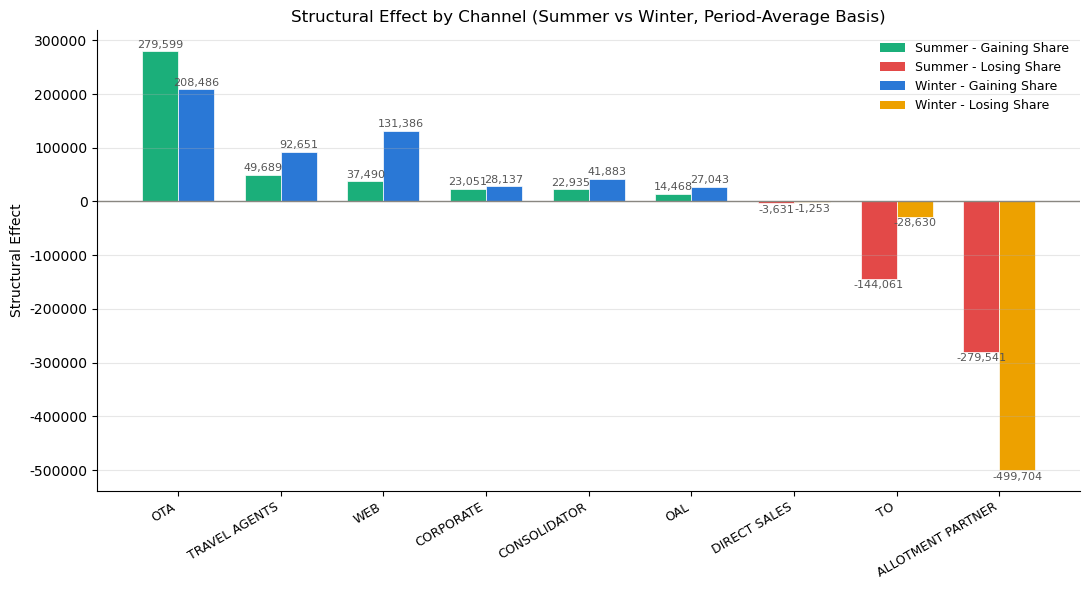

In [37]:
#  4.1.4 (Chart) Structural Effect by Channel: Summer vs Winter
import numpy as np
from matplotlib.patches import Patch

# sort by Structural_Effect_Summer, descending
plot_df = comparison.sort_values('Structural_Effect_Summer', ascending=False).reset_index(drop=True)

channels = plot_df['Sales_Upper_Channel']
summer_vals = plot_df['Structural_Effect_Summer']
winter_vals = plot_df['Structural_Effect_Winter']

x = np.arange(len(channels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

summer_colors = ['#1baf7a' if v >= 0 else '#e34948' for v in summer_vals]
winter_colors = ['#2a78d6' if v >= 0 else '#eda100' for v in winter_vals]

bars1 = ax.bar(x - width/2, summer_vals, width, label='Summer', color=summer_colors, edgecolor='white', linewidth=0.5)
bars2 = ax.bar(x + width/2, winter_vals, width, label='Winter', color=winter_colors, edgecolor='white', linewidth=0.5)

for bars in [bars1, bars2]:
    for b in bars:
        h = b.get_height()
        va = 'bottom' if h >= 0 else 'top'
        offset = 3000 if h >= 0 else -3000
        ax.text(b.get_x() + b.get_width()/2, h + offset, f'{h:,.0f}',
                ha='center', va=va, fontsize=8, color='#555555')

ax.axhline(0, color='#898781', linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(channels, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Structural Effect')
ax.set_title('Structural Effect by Channel (Summer vs Winter, Period-Average Basis)', fontsize=12)
ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [
    Patch(facecolor='#1baf7a', label='Summer - Gaining Share'),
    Patch(facecolor='#e34948', label='Summer - Losing Share'),
    Patch(facecolor='#2a78d6', label='Winter - Gaining Share'),
    Patch(facecolor='#eda100', label='Winter - Losing Share'),
]
ax.legend(handles=legend_elements, loc='upper right', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('Figure_4.2_Structural_Effect_by_Channel.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.2

In [38]:
#  4.2.0a (Final Version) Identify Transatlantic Long-Haul Routes: TourDestination is EAST COAST/WEST COAST, and Country is US/CA
df_ikont = df_final[df_final['TourDest_KONT_IKONT_CITY'] == 'IKONT'].copy()

TRANSATLANTIC_LABELS = ['EAST COAST', 'WEST COAST']
NORTH_AMERICA_COUNTRIES = ['US', 'CA']  

longhaul_mask = (
    df_ikont['TourDestination'].isin(TRANSATLANTIC_LABELS) &
    df_ikont['TourDest_Country'].isin(NORTH_AMERICA_COUNTRIES)
)
df_longhaul = df_ikont[longhaul_mask].copy()

assert df_longhaul.shape[0] > 0, "Filtered result is empty - check TRANSATLANTIC_LABELS/NORTH_AMERICA_COUNTRIES"

print(f"Transatlantic long-haul records: {df_longhaul.shape[0]}")
print(f"Distinct destination airports: {df_longhaul['TourDest_Airport'].nunique()}")
display(
    df_longhaul.groupby(['TourDestination', 'TourDest_Country', 'TourDest_Airport'], as_index=False)
    .agg(Total_Bkd=('Bkd', 'sum'))
    .sort_values('Total_Bkd', ascending=False)
)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 40, Finished, Available, Finished, False)

Transatlantic long-haul records: 1638041
Distinct destination airports: 20


SynapseWidget(Synapse.DataFrame, 0a1cc21d-871d-49fd-bb87-7fbed14a2f10)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 41, Finished, Available, Finished, False)

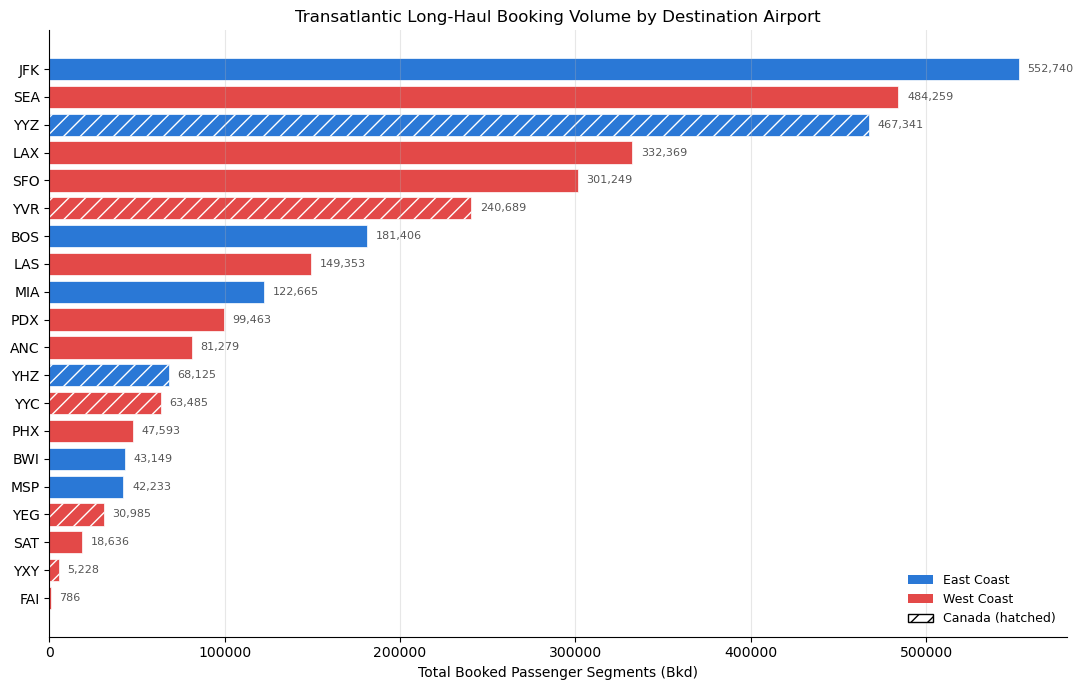

In [39]:
# ===== 4.2.2 (Chart) Transatlantic Long-Haul Route Booking Volume by Destination Airport =====
import matplotlib.pyplot as plt
import numpy as np
route_summary = (
    df_longhaul.groupby(['TourDestination', 'TourDest_Country', 'TourDest_Airport'], as_index=False)
    .agg(Total_Bkd=('Bkd', 'sum'))
    .sort_values('Total_Bkd', ascending=False)
    .reset_index(drop=True)
)

color_map = {'EAST COAST': '#2a78d6', 'WEST COAST': '#e34948'}
colors = [color_map[d] for d in route_summary['TourDestination']]
hatches = ['//' if c == 'CA' else '' for c in route_summary['TourDest_Country']]

fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.barh(route_summary['TourDest_Airport'], route_summary['Total_Bkd'],
                color=colors, edgecolor='white', linewidth=0.5)
for bar, hatch in zip(bars, hatches):
    bar.set_hatch(hatch)

ax.invert_yaxis()  
for bar, val in zip(bars, route_summary['Total_Bkd']):
    ax.text(val + 5000, bar.get_y() + bar.get_height()/2, f'{val:,.0f}',
            va='center', fontsize=8, color='#555555')

ax.set_xlabel('Total Booked Passenger Segments (Bkd)')
ax.set_title('Transatlantic Long-Haul Booking Volume by Destination Airport', fontsize=12)
ax.grid(axis='x', linestyle='-', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2a78d6', label='East Coast'),
    Patch(facecolor='#e34948', label='West Coast'),
    Patch(facecolor='white', edgecolor='black', hatch='//', label='Canada (hatched)'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
plt.savefig('Figure_4.3_Transatlantic_Route_Booking_Volume.png', dpi=300, bbox_inches='tight')
plt.show()

# 4.2.0b Flight-Level SLF Panel: Keep One Row per Core_Flight_Offer_id, with Time Dimensions and Phase Attached

In [40]:
flight_level = df_longhaul.drop_duplicates(subset=['Core_Flight_Offer_id']).copy()

flight_level = flight_level[[
    'Core_Flight_Offer_id', 'TourDestination', 'TourDest_Airport', 'TourDest_Country',
    'TourDep_Airport', 'RT_Report_Season', 'RT_Year_Month', 'Compartment',
    'flight_SLF', 'flight_cap', 'flight_total_bkd'
]].copy()

assert flight_level['Core_Flight_Offer_id'].is_unique, "Core_Flight_Offer_id not unique after dedup - check upstream merge"

# Season_Type / Year / TBY
s = flight_level['RT_Report_Season'].astype(str).str.strip().str.upper()
flight_level['Season_Type'] = np.select(
    condlist=[s.str.startswith('S'), s.str.startswith('W')],
    choicelist=['Summer', 'Winter'], default='Unknown'
)

flight_level['Year'] = np.nan
summer_mask = flight_level['Season_Type'] == 'Summer'
winter_mask = flight_level['Season_Type'] == 'Winter'
flight_level.loc[summer_mask, 'Year'] = flight_level.loc[summer_mask, 'RT_Report_Season'].str[1:3].astype('Int64')
flight_level.loc[winter_mask, 'Year'] = flight_level.loc[winter_mask, 'RT_Report_Season'].str[1:3].astype('Int64')
flight_level['Year'] = flight_level['Year'].fillna(99).astype(int)

flight_level.loc[summer_mask, 'TBY'] = 'TBY' + (flight_level.loc[summer_mask, 'Year'] - 1).astype(str) + '/' + flight_level.loc[summer_mask, 'Year'].astype(str)
flight_level.loc[winter_mask, 'TBY'] = 'TBY' + flight_level.loc[winter_mask, 'RT_Report_Season'].str[1:3] + '/' + flight_level.loc[winter_mask, 'RT_Report_Season'].str[3:5]

tby_mapping = {"TBY22/23": "TBY22/23", "TBY23/24": "TBY23/24", "TBY24/25": "TBY24/25", "TBY25/26": "TBY25/26 (partial)"}
flight_level['TBY'] = flight_level['TBY'].map(tby_mapping).fillna(flight_level['TBY'])

def get_phase(tby, season_type):
    if tby in ['TBY22/23', 'TBY23/24']:
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Winter':
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Summer':
        return 'Post'
    elif tby == 'TBY25/26 (partial)' and season_type == 'Winter':
        return 'Post'
    else:
        return None

flight_level['Phase'] = flight_level.apply(lambda r: get_phase(r['TBY'], r['Season_Type']), axis=1)

n_before = flight_level.shape[0]
flight_level = flight_level[flight_level['Phase'].notna()].copy()
n_after = flight_level.shape[0]

assert n_after > 0, "No flights remain after Phase assignment - check TBY/Season_Type logic"
print(f"Dropped {n_before - n_after} flights outside the defined Baseline/Post window (undefined Phase)")

print(f"\nFlight-level panel rows: {flight_level.shape[0]}")
print(f"SLF range: {flight_level['flight_SLF'].min():.3f} ~ {flight_level['flight_SLF'].max():.3f}")

print("\nCoverage by TBY x Season_Type x Phase:")
display(flight_level.groupby(['TBY', 'Season_Type', 'Phase'], as_index=False)['Core_Flight_Offer_id'].nunique())

display(flight_level.head(20))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 42, Finished, Available, Finished, False)

Dropped 2786 flights outside the defined Baseline/Post window (undefined Phase)

Flight-level panel rows: 11588
SLF range: 0.006 ~ 1.000

Coverage by TBY x Season_Type x Phase:


SynapseWidget(Synapse.DataFrame, 1d506321-3d98-4047-8d20-59a6f0d95e75)

SynapseWidget(Synapse.DataFrame, 243d28b7-e8b5-4bb9-bf4b-11ad65705c6b)

## 4.2.2 Route Grouping Criteria

In [41]:
# Identify self-operated feeder cities using flight volume growth magnitude =====

# Step 1: Filter for departures from FRA, self-operated by Condor (DE), non-transatlantic short/medium-haul flight legs
shorthaul_base_cond = (
    (df_final['Dep_Airport'] == 'FRA') &
    (df_final['Carrier'] == 'DE') &
    (~df_final['Dest_Country'].isin(['US', 'CA']))
)

df_shorthaul = df_final[shorthaul_base_cond].copy()
assert df_shorthaul.shape[0] > 0, "df_shorthaul is empty - check Dep_Airport/Carrier/Dest_Country values"

# Step 2: Deduplicate to flight level, separately construct TBY/Season_Type/Phase
df_shorthaul_flights = df_shorthaul.drop_duplicates(subset=['Core_Flight_Offer_id']).copy()

s = df_shorthaul_flights['RT_Report_Season'].astype(str).str.strip().str.upper()
df_shorthaul_flights['Season_Type'] = np.select(
    condlist=[s.str.startswith('S'), s.str.startswith('W')],
    choicelist=['Summer', 'Winter'], default='Unknown'
)

df_shorthaul_flights['Year'] = np.nan
summer_mask = df_shorthaul_flights['Season_Type'] == 'Summer'
winter_mask = df_shorthaul_flights['Season_Type'] == 'Winter'
df_shorthaul_flights.loc[summer_mask, 'Year'] = df_shorthaul_flights.loc[summer_mask, 'RT_Report_Season'].str[1:3].astype('Int64')
df_shorthaul_flights.loc[winter_mask, 'Year'] = df_shorthaul_flights.loc[winter_mask, 'RT_Report_Season'].str[1:3].astype('Int64')
df_shorthaul_flights['Year'] = df_shorthaul_flights['Year'].fillna(99).astype(int)

df_shorthaul_flights.loc[summer_mask, 'TBY'] = 'TBY' + (df_shorthaul_flights.loc[summer_mask, 'Year'] - 1).astype(str) + '/' + df_shorthaul_flights.loc[summer_mask, 'Year'].astype(str)
df_shorthaul_flights.loc[winter_mask, 'TBY'] = 'TBY' + df_shorthaul_flights.loc[winter_mask, 'RT_Report_Season'].str[1:3] + '/' + df_shorthaul_flights.loc[winter_mask, 'RT_Report_Season'].str[3:5]

tby_mapping = {"TBY22/23": "TBY22/23", "TBY23/24": "TBY23/24", "TBY24/25": "TBY24/25", "TBY25/26": "TBY25/26 (partial)"}
df_shorthaul_flights['TBY'] = df_shorthaul_flights['TBY'].map(tby_mapping).fillna(df_shorthaul_flights['TBY'])

def get_phase(tby, season_type):
    if tby in ['TBY22/23', 'TBY23/24']:
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Winter':
        return 'Baseline'
    elif tby == 'TBY24/25' and season_type == 'Summer':
        return 'Post'
    elif tby == 'TBY25/26 (partial)' and season_type == 'Winter':
        return 'Post'
    else:
        return None

df_shorthaul_flights['Phase'] = df_shorthaul_flights.apply(lambda r: get_phase(r['TBY'], r['Season_Type']), axis=1)
df_shorthaul_flights = df_shorthaul_flights[df_shorthaul_flights['Phase'].notna()].copy()

assert df_shorthaul_flights.shape[0] > 0, "No shorthaul flights remain after Phase assignment"

# Step 3: Count flight volume by destination x phase, compare growth multiples after annualizing
volume_compare = df_shorthaul_flights.groupby(['Dest_Airport', 'Phase'], as_index=False).agg(
    N_Flights=('Core_Flight_Offer_id', 'nunique')
)

volume_pivot = volume_compare.pivot_table(index='Dest_Airport', columns='Phase', values='N_Flights', fill_value=0)
for col in ['Baseline', 'Post']:
    if col not in volume_pivot.columns:
        volume_pivot[col] = 0

# Baseline covers TBY22/23+TBY23/24+TBY24/25 Winter, approx. 2.5 years; Post covers TBY24/25 Summer+TBY25/26 Winter, approx. 1 year
volume_pivot['Baseline_Annualized'] = volume_pivot['Baseline'] / 2.5
volume_pivot['Post_Annualized'] = volume_pivot['Post'] / 1.0
volume_pivot['Growth_Ratio'] = (volume_pivot['Post_Annualized'] + 1) / (volume_pivot['Baseline_Annualized'] + 1)

volume_pivot_sorted = volume_pivot.sort_values('Growth_Ratio', ascending=False).reset_index()

print("Destinations sorted by growth ratio (top 20 candidates for self-operated feeder cities):")
display(volume_pivot_sorted.head(20).round(2))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 43, Finished, Available, Finished, False)

Destinations sorted by growth ratio (top 20 candidates for self-operated feeder cities):


SynapseWidget(Synapse.DataFrame, 91715c81-6085-4033-aa7e-d2649c23a80e)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 44, Finished, Available, Finished, False)

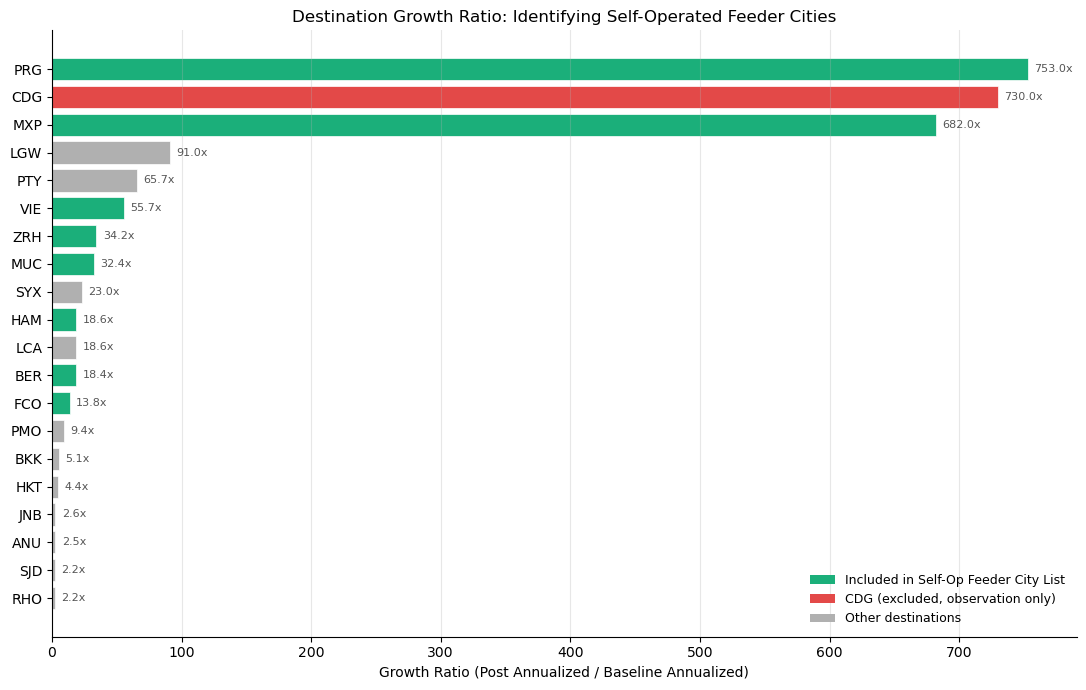

In [42]:
# Destination Growth Ratio (Baseline vs Post, Annualized) =====
plot_df = volume_pivot_sorted.head(20).copy()

SELF_OP_FEEDER_CITIES = ['PRG', 'MXP', 'VIE', 'ZRH', 'MUC', 'HAM', 'BER', 'FCO']
colors = ['#1baf7a' if d in SELF_OP_FEEDER_CITIES else ('#e34948' if d == 'CDG' else '#b0b0b0')
          for d in plot_df['Dest_Airport']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(plot_df['Dest_Airport'], plot_df['Growth_Ratio'], color=colors, edgecolor='white', linewidth=0.5)
ax.invert_yaxis()

for bar, val in zip(bars, plot_df['Growth_Ratio']):
    ax.text(val + 5, bar.get_y() + bar.get_height()/2, f'{val:,.1f}x', va='center', fontsize=8, color='#555555')

ax.set_xlabel('Growth Ratio (Post Annualized / Baseline Annualized)')
ax.set_title('Destination Growth Ratio: Identifying Self-Operated Feeder Cities', fontsize=12)
ax.grid(axis='x', linestyle='-', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#1baf7a', label='Included in Self-Op Feeder City List'),
    Patch(facecolor='#e34948', label='CDG (excluded, observation only)'),
    Patch(facecolor='#b0b0b0', label='Other destinations'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()

plt.show()

In [43]:
# ===== 4.2 Determine the List of Self-Operated Feeder Cities =====

SELF_OP_FEEDER_CITIES = ['PRG', 'MXP', 'VIE', 'ZRH', 'MUC', 'HAM', 'BER', 'FCO']
# Note: In the reverse-engineered results, CDG (Paris) also shows a very high growth multiple (730x),
# but it is not among the 8 self-operated feeder cities listed in Section 1.3 of the paper.
# It is separately recorded as a potential 9th new route, not included as a basis for grouping,
# and noted as an observation in the paper.

print(f"Officially adopted list of self-operated feeder cities ({len(SELF_OP_FEEDER_CITIES)}): {SELF_OP_FEEDER_CITIES}")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 45, Finished, Available, Finished, False)

Officially adopted list of self-operated feeder cities (8): ['PRG', 'MXP', 'VIE', 'ZRH', 'MUC', 'HAM', 'BER', 'FCO']


In [44]:
# 4.2 Route Grouping Explanation Table - Proportion of Baseline Period POC Falling in Self-Operated Feeder Cities

baseline_flight_ids = flight_level.loc[flight_level['Phase'] == 'Baseline', 'Core_Flight_Offer_id']
baseline_book = df_longhaul[df_longhaul['Core_Flight_Offer_id'].isin(baseline_flight_ids)].copy()

assert baseline_book.shape[0] > 0, "baseline_book is empty"

baseline_book['Is_FeederCity_POC'] = baseline_book['POC_Airport'].isin(SELF_OP_FEEDER_CITIES)
baseline_book['FeederCity_Bkd'] = np.where(baseline_book['Is_FeederCity_POC'], baseline_book['Bkd'], 0)

route_proxy = baseline_book.groupby('TourDest_Airport', as_index=False).agg(
    Total_Bkd=('Bkd', 'sum'),
    FeederCity_Bkd=('FeederCity_Bkd', 'sum')
)
route_proxy['FeederCity_Share'] = route_proxy['FeederCity_Bkd'] / route_proxy['Total_Bkd']

median_share = route_proxy['FeederCity_Share'].median()
route_proxy['Connectivity_Group'] = np.where(
    route_proxy['FeederCity_Share'] >= median_share, 'High-Connectivity', 'Low-Connectivity'
)

assert route_proxy.shape[0] > 0, "route_proxy is empty - check POC_Airport values"

print(f"Grouping threshold (median FeederCity_Share): {median_share:.4f}")
print("\n===== Route Classification Table =====")
display(route_proxy.sort_values('FeederCity_Share', ascending=False).round(4))

route_group_map = route_proxy.set_index('TourDest_Airport')['Connectivity_Group'].to_dict()
flight_level['Connectivity_Group'] = flight_level['TourDest_Airport'].map(route_group_map)

print("\nFlights per group:")
display(flight_level.groupby('Connectivity_Group', as_index=False).agg(N_Flights=('Core_Flight_Offer_id', 'nunique')))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 46, Finished, Available, Finished, False)

Grouping threshold (median FeederCity_Share): 0.0517

===== Route Classification Table =====


SynapseWidget(Synapse.DataFrame, aaad90f0-6c88-4c62-bc9c-a4212923a85c)


Flights per group:


SynapseWidget(Synapse.DataFrame, c51881e2-fdd1-432d-a6d1-e929ed32cc0c)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 47, Finished, Available, Finished, False)

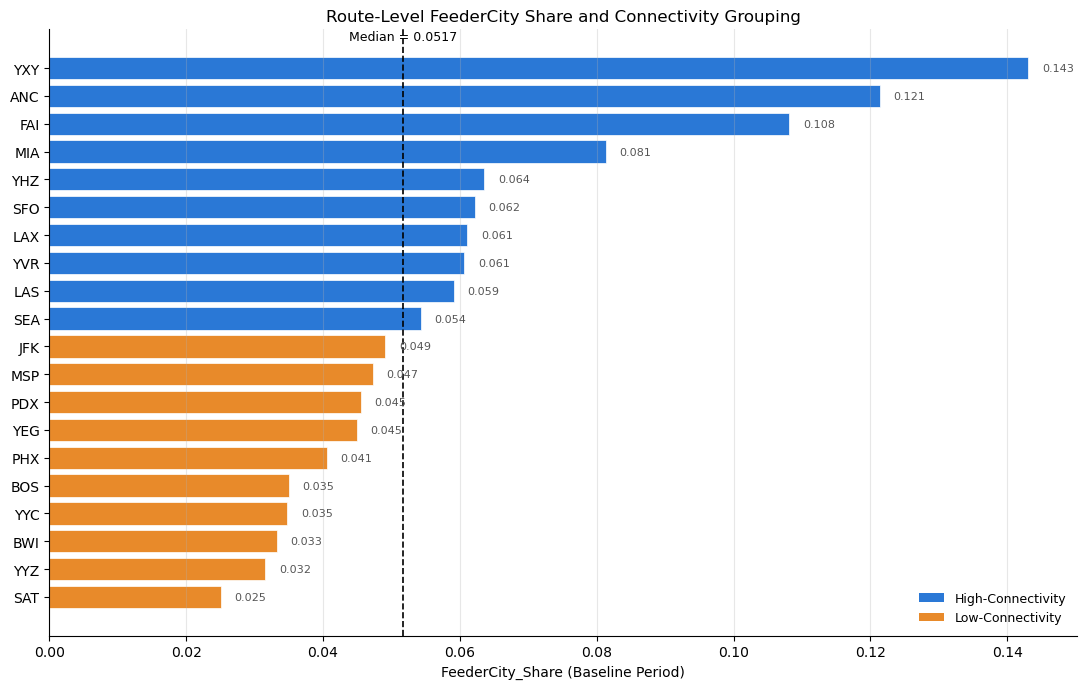

In [45]:
#  Route-Level FeederCity_Share and Connectivity Grouping 
import matplotlib.pyplot as plt

plot_df2 = route_proxy.sort_values('FeederCity_Share', ascending=False).reset_index(drop=True)

colors2 = ['#2a78d6' if g == 'High-Connectivity' else '#e88a2a' for g in plot_df2['Connectivity_Group']]

fig, ax = plt.subplots(figsize=(11, 7))
bars = ax.barh(plot_df2['TourDest_Airport'], plot_df2['FeederCity_Share'], color=colors2, edgecolor='white', linewidth=0.5)
ax.invert_yaxis()

ax.axvline(median_share, color='black', linestyle='--', linewidth=1.2)
ax.text(median_share, -1.0, f'Median = {median_share:.4f}', ha='center', fontsize=9, color='black')

for bar, val in zip(bars, plot_df2['FeederCity_Share']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=8, color='#555555')

ax.set_xlabel('FeederCity_Share (Baseline Period)')
ax.set_title('Route-Level FeederCity Share and Connectivity Grouping', fontsize=12)
ax.grid(axis='x', linestyle='-', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2a78d6', label='High-Connectivity'),
    Patch(facecolor='#e88a2a', label='Low-Connectivity'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9, frameon=False)

plt.tight_layout()
plt.show()

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 48, Finished, Available, Finished, False)

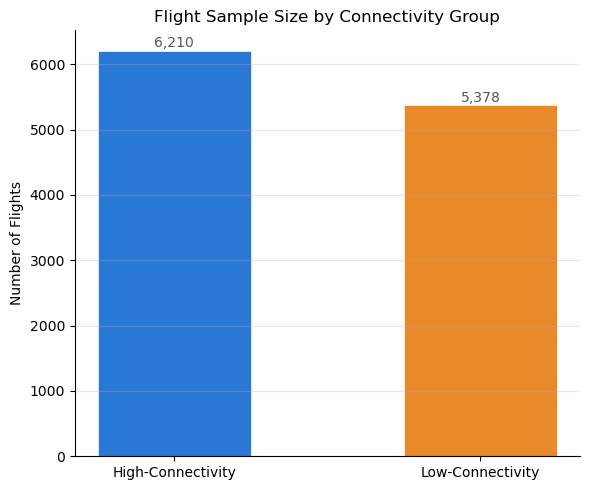

In [46]:
# Flight Sample Size by Connectivity Group 
import matplotlib.pyplot as plt

group_counts = flight_level.groupby('Connectivity_Group', as_index=False).agg(N_Flights=('Core_Flight_Offer_id', 'nunique'))

fig, ax = plt.subplots(figsize=(6, 5))
colors3 = ['#2a78d6', '#e88a2a']
bars = ax.bar(group_counts['Connectivity_Group'], group_counts['N_Flights'], color=colors3, edgecolor='white', linewidth=0.5, width=0.5)

for bar, val in zip(bars, group_counts['N_Flights']):
    ax.text(bar.get_x() + bar.get_width()/2, val + 50, f'{val:,}', ha='center', fontsize=10, color='#555555')

ax.set_ylabel('Number of Flights')
ax.set_title('Flight Sample Size by Connectivity Group', fontsize=12)
ax.grid(axis='y', linestyle='-', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 4.2.3 Overall SLF Trend and Structural Break Testing  

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 49, Finished, Available, Finished, False)

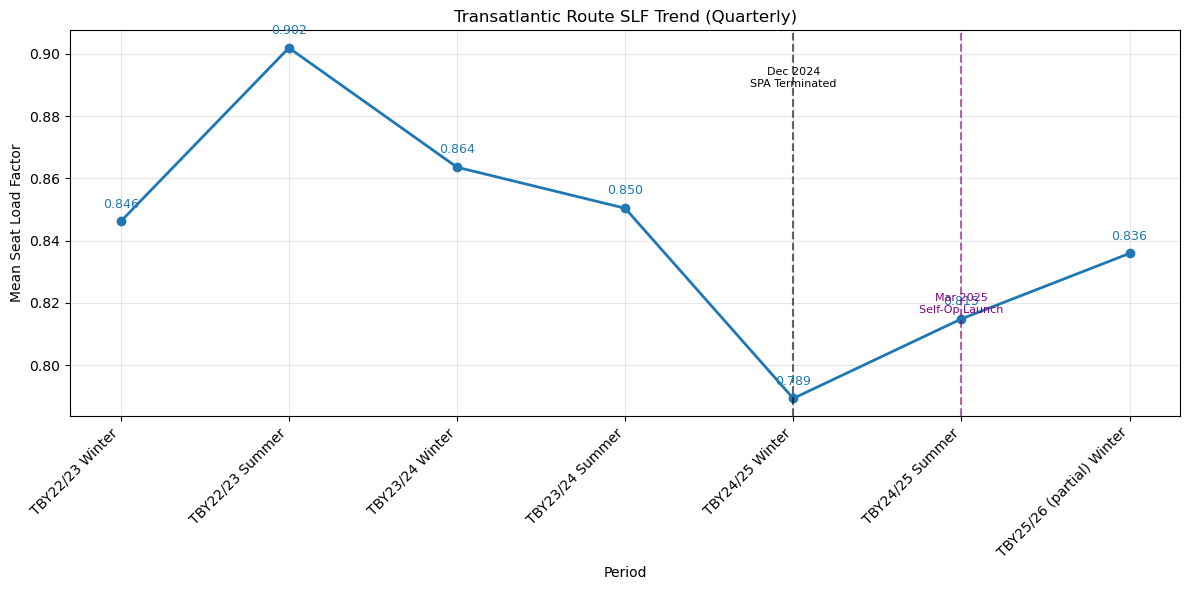

SLF by period:


SynapseWidget(Synapse.DataFrame, 6d44662d-0190-4965-a1a1-ae628815f1cf)

In [47]:
# ===== 4.2 Part A1Quarterly SLF Time Series Chart, Marking Two Breakpoints + Data Point Value Labels =====

season_order = {'Winter': 0, 'Summer': 1}
flight_level['Season_Order'] = flight_level['Season_Type'].map(season_order)
flight_level_sorted = flight_level.sort_values(['TBY', 'Season_Order'])
flight_level_sorted['Period'] = flight_level_sorted['TBY'] + ' ' + flight_level_sorted['Season_Type']
period_order = flight_level_sorted[['Period']].drop_duplicates()['Period'].tolist()

slf_ts = flight_level_sorted.groupby('Period', as_index=False).agg(
    Mean_SLF=('flight_SLF', 'mean'),
    N_Flights=('Core_Flight_Offer_id', 'nunique')
)

assert slf_ts.shape[0] > 0, "SLF time series is empty - check flight_level construction"

plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

fig, ax = plt.subplots(figsize=(12, 6))
slf_ts_ordered = slf_ts.set_index('Period').reindex(period_order)
ax.plot(period_order, slf_ts_ordered['Mean_SLF'], marker='o', linewidth=2, color='tab:blue')

for i, val in enumerate(slf_ts_ordered['Mean_SLF']):
    ax.annotate(f'{val:.3f}', (i, val), textcoords="offset points", xytext=(0, 10),
                ha='center', fontsize=9, color='tab:blue')

if 'TBY24/25 Winter' in period_order:
    idx1 = period_order.index('TBY24/25 Winter')
    ax.axvline(idx1, color='black', linestyle='--', alpha=0.6)
    ax.text(idx1, ax.get_ylim()[1] * 0.98, 'Dec 2024\nSPA Terminated', color='black', fontsize=8, ha='center')

if 'TBY24/25 Summer' in period_order:
    idx2 = period_order.index('TBY24/25 Summer')
    ax.axvline(idx2, color='purple', linestyle='--', alpha=0.6)
    ax.text(idx2, ax.get_ylim()[1] * 0.9, 'Mar 2025\nSelf-Op Launch', color='purple', fontsize=8, ha='center')

ax.set_title('Transatlantic Route SLF Trend (Quarterly)')
ax.set_ylabel('Mean Seat Load Factor')
ax.set_xlabel('Period')
ax.grid(alpha=0.3)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

slf_ts_display = slf_ts_ordered.copy()
slf_ts_display.index.name = 'Period'
print("SLF by period:")
display(slf_ts_display.reset_index().round(4))

In [48]:
# ===== 4.2 Part A2: Monthly SLF Panel + ITS Segmented Regression + Chow Test =====
from scipy import stats
import statsmodels.formula.api as smf

# Aggregate SLF by month (no longer using quarterly Phase; directly use RT_Year_Month to precisely locate breakpoints)
monthly_slf = flight_level.groupby('RT_Year_Month', as_index=False).agg(
    Mean_SLF=('flight_SLF', 'mean'),
    N_Flights=('Core_Flight_Offer_id', 'nunique')
).sort_values('RT_Year_Month').reset_index(drop=True)

assert monthly_slf.shape[0] > 0, "Monthly panel is empty"

monthly_slf['t'] = np.arange(len(monthly_slf))

# Breakpoints: 2024-12 (prior feeder arrangement ended), 2025-03 (self-operated feeder first flight) 
# — format previously confirmed via screenshot as 'YYYY-MM'
BREAK1_MONTH = '2024-12'
BREAK2_MONTH = '2025-03'

monthly_slf['D1'] = (monthly_slf['RT_Year_Month'] >= BREAK1_MONTH).astype(int)
monthly_slf['D2'] = (monthly_slf['RT_Year_Month'] >= BREAK2_MONTH).astype(int)
monthly_slf['t_since_D1'] = np.where(monthly_slf['D1'] == 1, monthly_slf['t'] - monthly_slf.loc[monthly_slf['D1'] == 1, 't'].min(), 0)
monthly_slf['t_since_D2'] = np.where(monthly_slf['D2'] == 1, monthly_slf['t'] - monthly_slf.loc[monthly_slf['D2'] == 1, 't'].min(), 0)

print("Monthly SLF series with breakpoint dummies:")
display(monthly_slf)

# ITS segmented regression
its_model = smf.ols('Mean_SLF ~ t + D1 + t_since_D1 + D2 + t_since_D2', data=monthly_slf).fit(cov_type='HC1')

print("\n===== ITS Segmented Regression Results =====")
its_result_table = pd.DataFrame({
    'Coefficient': its_model.params, 'Std_Error': its_model.bse, 'p_value': its_model.pvalues
}).round(4)
its_result_table = its_result_table.reset_index().rename(columns={'index': 'Variable'})
display(its_result_table)
print("Interpretation: D1/D2 = level shift at each breakpoint; t_since_D1/t_since_D2 = change in trend slope after each breakpoint")

# Chow test: whether there is an overall structural difference between the regressions before and after the breakpoint
def chow_test(df, break_col, time_col='t', y_col='Mean_SLF'):
    pre = df[df[break_col] == 0]
    post = df[df[break_col] == 1]
    if len(pre) < 3 or len(post) < 3:
        return None
    full_model = smf.ols(f'{y_col} ~ {time_col}', data=df).fit()
    pre_model = smf.ols(f'{y_col} ~ {time_col}', data=pre).fit()
    post_model = smf.ols(f'{y_col} ~ {time_col}', data=post).fit()

    rss_pooled = sum(full_model.resid ** 2)
    rss_split = sum(pre_model.resid ** 2) + sum(post_model.resid ** 2)
    k = 2
    n = len(df)
    f_stat = ((rss_pooled - rss_split) / k) / (rss_split / (n - 2 * k))
    p_val = 1 - stats.f.cdf(f_stat, k, n - 2 * k)
    return f_stat, p_val

chow_records = []
for break_col, label in [('D1', 'Dec 2024 (Prior Feeder Arrangement Ended)'), ('D2', 'Mar 2025 (Self-Op Launch)')]:
    result = chow_test(monthly_slf, break_col)
    if result:
        f_stat, p_val = result
        chow_records.append({'Breakpoint': label, 'F_stat': round(f_stat, 3), 'p_value': round(p_val, 4)})
    else:
        chow_records.append({'Breakpoint': label, 'F_stat': np.nan, 'p_value': np.nan, 'Note': 'Insufficient sample'})

print("\n===== Chow Test Results =====")
display(pd.DataFrame(chow_records))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 50, Finished, Available, Finished, False)

Monthly SLF series with breakpoint dummies:


SynapseWidget(Synapse.DataFrame, a9a42c9a-429d-4cd1-81df-64934ae59b11)


===== ITS Segmented Regression Results =====


SynapseWidget(Synapse.DataFrame, a4bb1056-3f2a-4b8d-a161-c2bc6097b410)

2026-07-24:02:18:12,115 ERROR    [shared_platform_utils.py:82] Create MLExperiment failed, status_code: 403, b'{"requestId":"ad192475-da55-400a-9af2-475f736f459a","errorCode":"FeatureNotAvailable","message":"The feature is not available","isRetriable":false}'
2026-07-24:02:18:12,119 ERROR    [synapse_mlflow_utils.py:390] [fabric mlflow plugin]: <class 'synapse.ml.mlflow.tracking_store.TridentMLflowTrackingStore'>.create_experiment exception 'NoneType' object has no attribute 'properties'
2026-07-24:02:18:12,121 ERROR    [default_experiment_registry.py:55] Error find or created notebook/SJD default experiment, please call mlflow.set_experiment to set a valid one before run
Traceback (most recent call last):
  File "/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/synapse/ml/mlflow/default_experiment_registry.py", line 52, in get_experiment_id
    return mlflow.set_experiment(f"{artifact_name}").experiment_id
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


===== Chow Test Results =====


SynapseWidget(Synapse.DataFrame, 48d4bb92-7cc2-4757-8564-76062084f01c)

## 4.2.4 High vs Low Connectivity Group Comparison

In [49]:
# 4.2 Part C3: SLF Comparison Table for Two Route Groups 

group_compare = flight_level[flight_level['Connectivity_Group'].notna()].groupby(
    ['Connectivity_Group', 'Phase'], as_index=False
).agg(
    Mean_SLF=('flight_SLF', 'mean'),
    Std_SLF=('flight_SLF', 'std'),
    N_Flights=('Core_Flight_Offer_id', 'nunique')
)

print("===== Group x Phase SLF Summary =====")
display(group_compare.round(4))

pivot_compare = group_compare.pivot_table(index='Connectivity_Group', columns='Phase', values='Mean_SLF')
pivot_compare['Change'] = pivot_compare['Post'] - pivot_compare['Baseline']
pivot_compare['Change_Pct'] = (pivot_compare['Change'] / pivot_compare['Baseline'] * 100).round(2)

pivot_compare_display = pivot_compare.copy()
pivot_compare_display.index.name = 'Connectivity_Group'

print("\n===== Change Summary Table =====")
display(pivot_compare_display.reset_index().round(4))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 51, Finished, Available, Finished, False)

===== Group x Phase SLF Summary =====


SynapseWidget(Synapse.DataFrame, 73806a99-9823-4662-ad88-460514988df9)


===== Change Summary Table =====


SynapseWidget(Synapse.DataFrame, fb1b19fc-eee0-414a-9f17-c25a51ac1150)

In [50]:
# 4.2 Part C4: Two-Group Difference Test - t-Test + DID Regression
from scipy import stats
import statsmodels.formula.api as smf

flight_level_c4 = flight_level[
    flight_level['Connectivity_Group'].notna() & flight_level['Phase'].isin(['Baseline', 'Post'])
].copy()

# Independent samples t-test: test separately whether the means of the two groups differ significantly during the Baseline period and the Post period
ttest_records = []
for phase in ['Baseline', 'Post']:
    high = flight_level_c4[(flight_level_c4['Connectivity_Group'] == 'High-Connectivity') & (flight_level_c4['Phase'] == phase)]['flight_SLF']
    low = flight_level_c4[(flight_level_c4['Connectivity_Group'] == 'Low-Connectivity') & (flight_level_c4['Phase'] == phase)]['flight_SLF']
    if len(high) > 1 and len(low) > 1:
        t_stat, p_val = stats.ttest_ind(high, low, equal_var=False)
        ttest_records.append({'Phase': phase, 't_stat': round(t_stat, 3), 'p_value': round(p_val, 4),
                               'N_High': len(high), 'N_Low': len(low)})
    else:
        ttest_records.append({'Phase': phase, 't_stat': np.nan, 'p_value': np.nan,
                               'N_High': len(high), 'N_Low': len(low), 'Note': 'Insufficient sample'})

print("===== t-test Results =====")
display(pd.DataFrame(ttest_records))

# DID
did_data = flight_level_c4.copy()
did_data['Treat'] = (did_data['Connectivity_Group'] == 'High-Connectivity').astype(int)
did_data['Post_D'] = (did_data['Phase'] == 'Post').astype(int)
did_data['Treat_Post'] = did_data['Treat'] * did_data['Post_D']

did_model = smf.ols('flight_SLF ~ Treat + Post_D + Treat_Post', data=did_data).fit(cov_type='HC1')

did_result_table = pd.DataFrame({
    'Coefficient': did_model.params, 'Std_Error': did_model.bse, 'p_value': did_model.pvalues
}).round(4)
did_result_table.index.name = 'Variable'

print("\n===== DID Regression Results =====")
display(did_result_table.reset_index())
print("Interpretation: Treat_Post coefficient = DID estimator (differential SLF change for High-Connectivity group vs Low-Connectivity group)")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 52, Finished, Available, Finished, False)

===== t-test Results =====


SynapseWidget(Synapse.DataFrame, 97f13029-f182-498a-93d4-37295cef1743)


===== DID Regression Results =====


SynapseWidget(Synapse.DataFrame, 096191e6-3457-4fb4-93a3-8fdef2dd5e58)

Interpretation: Treat_Post coefficient = DID estimator (differential SLF change for High-Connectivity group vs Low-Connectivity group)


## 4.2.5 Post-hoc Validation 

In [51]:
# ===== 4.2 Part B1: Actual DE_Feeder_YN Connecting Flight Structure vs SLF Comparison for 2025 (Post Period) =====

post_flight_ids = flight_level.loc[flight_level['Phase'] == 'Post', 'Core_Flight_Offer_id']
post2025_book = df_longhaul[df_longhaul['Core_Flight_Offer_id'].isin(post_flight_ids)].copy()

assert post2025_book.shape[0] > 0, "post2025_book is empty - check Phase assignment in flight_level"

# DE_Feeder_YN is a booking-level field; first look at its raw distribution during the Post period (by booking, i.e., weighted by Bkd)
feeder_raw_dist = post2025_book.groupby('DE_Feeder_YN', as_index=False).agg(
    Total_Bkd=('Bkd', 'sum')
)
feeder_raw_dist['Share'] = (feeder_raw_dist['Total_Bkd'] / feeder_raw_dist['Total_Bkd'].sum() * 100).round(2)
print("===== Distribution of DE_Feeder_YN in 2025 Transatlantic Long-Haul Flight Bookings =====")
display(feeder_raw_dist.sort_values('Total_Bkd', ascending=False))

# Aggregate to flight level: for each flight's bookings, whether Y/N/N/A each appeared (a single flight may have all three passenger types simultaneously)
feeder_flight_flags = post2025_book.groupby('Core_Flight_Offer_id', as_index=False).agg(
    Has_Y=('DE_Feeder_YN', lambda x: (x == 'Y').any()),
    Has_N=('DE_Feeder_YN', lambda x: (x == 'N').any()),
    Has_NA=('DE_Feeder_YN', lambda x: (x == 'N/A').any())
)

flight_level_post = flight_level[flight_level['Phase'] == 'Post'].merge(
    feeder_flight_flags, on='Core_Flight_Offer_id', how='left'
)

# Assign each flight a dominant label based on the dominant type (the DE_Feeder_YN category with the highest booking volume for that flight)
def dominant_feeder_type(fid):
    sub = post2025_book[post2025_book['Core_Flight_Offer_id'] == fid]
    bkd_by_type = sub.groupby('DE_Feeder_YN')['Bkd'].sum()
    return bkd_by_type.idxmax() if len(bkd_by_type) > 0 else 'N/A'

dominant_map = post2025_book.groupby('Core_Flight_Offer_id').apply(
    lambda g: g.groupby('DE_Feeder_YN')['Bkd'].sum().idxmax()
)
flight_level_post['Dominant_Feeder_Type'] = flight_level_post['Core_Flight_Offer_id'].map(dominant_map)

label_map = {'Y': 'Condor Feeder Identified', 'N': 'No Condor Feeder Identified', 'N/A': 'Feeder Status Not Assessable'}
flight_level_post['Feeder_Label'] = flight_level_post['Dominant_Feeder_Type'].map(label_map)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 53, Finished, Available, Finished, False)

===== Distribution of DE_Feeder_YN in 2025 Transatlantic Long-Haul Flight Bookings =====


SynapseWidget(Synapse.DataFrame, e1588286-9af7-4676-b7ec-165c67e9456f)

In [52]:
# ===== 4.2 Part B1 (Continued): Flight-Level SLF Comparison Table =====

feeder_flight_flags = post2025_book.groupby('Core_Flight_Offer_id', as_index=False).agg(
    Has_Y=('DE_Feeder_YN', lambda x: (x == 'Y').any()),
    Has_N=('DE_Feeder_YN', lambda x: (x == 'N').any()),
    Has_NA=('DE_Feeder_YN', lambda x: (x == 'N/A').any())
)

flight_level_post = flight_level[flight_level['Phase'] == 'Post'].merge(
    feeder_flight_flags, on='Core_Flight_Offer_id', how='left'
)

# The "dominant connecting type" for each flight = the DE_Feeder_YN category with the highest booking volume for that flight
dominant_map = post2025_book.groupby('Core_Flight_Offer_id').apply(
    lambda g: g.groupby('DE_Feeder_YN')['Bkd'].sum().idxmax()
)
flight_level_post['Dominant_Feeder_Type'] = flight_level_post['Core_Flight_Offer_id'].map(dominant_map)

label_map = {'Y': 'Condor Feeder Identified', 'N': 'No Condor Feeder Identified', 'N/A': 'Feeder Status Not Assessable'}
flight_level_post['Feeder_Label'] = flight_level_post['Dominant_Feeder_Type'].map(label_map)

assert flight_level_post['Feeder_Label'].notna().all(), "Some flights have unmapped Dominant_Feeder_Type - check DE_Feeder_YN values"

feeder_slf_compare = flight_level_post.groupby('Feeder_Label', as_index=False).agg(
    Mean_SLF=('flight_SLF', 'mean'),
    Std_SLF=('flight_SLF', 'std'),
    N_Flights=('Core_Flight_Offer_id', 'nunique')
)

print("===== Flight-Level SLF Comparison Table by Dominant Connecting Type (2025 Transatlantic Long-Haul Flights) =====")
display(feeder_slf_compare.round(4))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 54, Finished, Available, Finished, False)

===== Flight-Level SLF Comparison Table by Dominant Connecting Type (2025 Transatlantic Long-Haul Flights) =====


SynapseWidget(Synapse.DataFrame, 2b20668c-ce6f-49bc-ae93-2cc5a72b9a61)

In [53]:
# ===== 4.2 Part B2: Independent Samples t-Test - Connecting Flights vs Unidentified Connecting Flights =====
from scipy import stats

feeder_yes = flight_level_post[flight_level_post['Feeder_Label'] == 'Condor Feeder Identified']['flight_SLF']
feeder_no = flight_level_post[flight_level_post['Feeder_Label'] == 'No Condor Feeder Identified']['flight_SLF']

print(f"Condor Feeder Identified: n={len(feeder_yes)}, mean={feeder_yes.mean():.4f}, std={feeder_yes.std():.4f}")
print(f"No Condor Feeder Identified: n={len(feeder_no)}, mean={feeder_no.mean():.4f}, std={feeder_no.std():.4f}")

t_stat, p_val = stats.ttest_ind(feeder_yes, feeder_no, equal_var=False)
print(f"\nWelch's t-test: t={t_stat:.3f}, p={p_val:.4f}")

pooled_std = np.sqrt((feeder_yes.var() + feeder_no.var()) / 2)
cohens_d = (feeder_yes.mean() - feeder_no.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.3f}")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 55, Finished, Available, Finished, False)

Condor Feeder Identified: n=35, mean=0.8717, std=0.0983
No Condor Feeder Identified: n=3602, mean=0.8180, std=0.1322

Welch's t-test: t=3.205, p=0.0029
Cohen's d: 0.461


In [54]:
# ===== 4.2 Part C5: Using the Actual 2025 Feeder Field to Reverse-Validate Whether the Baseline Period Grouping (C2) Direction Is Reasonable =====

post_flight_ids = flight_level.loc[flight_level['Phase'] == 'Post', 'Core_Flight_Offer_id']
post2025_book_c5 = df_longhaul[df_longhaul['Core_Flight_Offer_id'].isin(post_flight_ids)].copy()

assert post2025_book_c5.shape[0] > 0, "post2025_book_c5 is empty"

# Actual connecting-flight share for each long-haul route (by TourDest_Airport) in 2025 (calculated by booking volume, including all three categories Y/N/N/A)
post2025_book_c5['Is_Y'] = post2025_book_c5['DE_Feeder_YN'] == 'Y'
post2025_book_c5['Y_Bkd'] = np.where(post2025_book_c5['Is_Y'], post2025_book_c5['Bkd'], 0)

route_feeder_2025 = post2025_book_c5.groupby('TourDest_Airport', as_index=False).agg(
    Total_Bkd_2025=('Bkd', 'sum'),
    Y_Bkd_2025=('Y_Bkd', 'sum')
)
route_feeder_2025['Real_Feeder_Share_2025'] = route_feeder_2025['Y_Bkd_2025'] / route_feeder_2025['Total_Bkd_2025']

# Merge in the group labels from C2 (based on the baseline period proxy)
route_feeder_2025 = route_feeder_2025.merge(
    route_proxy[['TourDest_Airport', 'Connectivity_Group', 'FeederCity_Share']],
    on='TourDest_Airport', how='left'
)

assert route_feeder_2025['Connectivity_Group'].notna().any(), "No routes matched between 2025 data and C2 grouping"

print("===== Route Level: Baseline Period Proxy Grouping vs Actual 2025 Connecting-Flight Share =====")
display(route_feeder_2025.sort_values('Real_Feeder_Share_2025', ascending=False).round(4))

# Summary comparison: whether the mean actual connecting-flight share in 2025 shows a directional difference between the two groups
crosscheck = route_feeder_2025.groupby('Connectivity_Group', as_index=False).agg(
    Mean_Real_Feeder_Share_2025=('Real_Feeder_Share_2025', 'mean'),
    N_Routes=('TourDest_Airport', 'nunique')
)

print("\n===== Reverse Validation: Whether the Direction of the C2 Grouping Is Reasonable (the High-Proxy Group Should Have a Higher Actual Connecting-Flight Share in 2025) =====")
display(crosscheck.round(4))

# Independent samples t-test: whether Real_Feeder_Share_2025 differs significantly between the two groups (route-level observations, small sample size, for reference only)
from scipy import stats
high_share = route_feeder_2025[route_feeder_2025['Connectivity_Group']=='High-Connectivity']['Real_Feeder_Share_2025'].dropna()
low_share = route_feeder_2025[route_feeder_2025['Connectivity_Group']=='Low-Connectivity']['Real_Feeder_Share_2025'].dropna()

if len(high_share) > 1 and len(low_share) > 1:
    t_stat, p_val = stats.ttest_ind(high_share, low_share, equal_var=False)
    print(f"\nt-test (route-level, n_high={len(high_share)}, n_low={len(low_share)}): t={t_stat:.3f}, p={p_val:.4f}")
else:
    print(f"\nInsufficient sample size for t-test (n_high={len(high_share)}, n_low={len(low_share)})")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 56, Finished, Available, Finished, False)

===== Route Level: Baseline Period Proxy Grouping vs Actual 2025 Connecting-Flight Share =====


SynapseWidget(Synapse.DataFrame, 4b243e4a-259a-4fe7-bce9-591c608e3b5a)


===== Reverse Validation: Whether the Direction of the C2 Grouping Is Reasonable (the High-Proxy Group Should Have a Higher Actual Connecting-Flight Share in 2025) =====


SynapseWidget(Synapse.DataFrame, 60a8c4dc-ed53-45cc-855f-f183167ff50c)


t-test (route-level, n_high=7, n_low=5): t=0.366, p=0.7244


# 4.3 Route Revenue and Fare Yield Analysis (Corresponding to RQ3)

In [55]:
# ===== 4.3 Part A Create booking_longhaul, Avoiding Season_Type Column Name Conflict =====
flight_meta_cols = ['Core_Flight_Offer_id', 'TBY', 'Season_Type', 'Phase', 'Connectivity_Group']

# df_longhaul already has its own Season_Type (from df_final in Section 4.1); drop it first,
# and consistently use the one from flight_level instead
# (flight_level's Season_Type/TBY/Phase were recalculated in Section 4.2, and are fully consistent with this section's basis)
df_longhaul_clean = df_longhaul.drop(columns=['Season_Type'], errors='ignore')

booking_longhaul = df_longhaul_clean.merge(
    flight_level[flight_meta_cols],
    on='Core_Flight_Offer_id', how='inner'
)
assert booking_longhaul.shape[0] > 0, "booking_longhaul is empty - check merge keys"

booking_longhaul = booking_longhaul[
    booking_longhaul['Yield'].notna() & (booking_longhaul['Yield'] > 0)
].copy()

print(f"Booking-level sample size for Yield analysis: {booking_longhaul.shape[0]}")
print(f"Yield range: {booking_longhaul['Yield'].min():.2f} ~ {booking_longhaul['Yield'].max():.2f}")

# Check column names to confirm there are no _x/_y suffix conflicts
print([c for c in booking_longhaul.columns if 'Season_Type' in c or 'TBY' in c or 'Phase' in c])

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 57, Finished, Available, Finished, False)

Booking-level sample size for Yield analysis: 1480121
Yield range: 0.01 ~ 7866.61
['TBY', 'Season_Type', 'Phase']


In [56]:
#  4.3.1 Part B: Table 4-8 Yield Descriptive Statistics Table 
yield_desc = booking_longhaul.groupby(
    ['TourDestination', 'Sales_Upper_Channel', 'Season_Type'], as_index=False
).agg(
    Mean_Yield=('Yield', 'mean'),
    Std_Yield=('Yield', 'std'),
    N_Bookings=('Bkd', 'count')
).sort_values('N_Bookings', ascending=False)

print("\n Yield Descriptive Statistics (Route x Channel x Season) =====")
display(yield_desc.round(2))


StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 58, Finished, Available, Finished, False)


 Yield Descriptive Statistics (Route x Channel x Season) =====


SynapseWidget(Synapse.DataFrame, eb0c8008-ff30-4bab-ba98-eed10db92979)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 59, Finished, Available, Finished, False)


 Yield Descriptive Statistics (Route x Channel x Season) 


SynapseWidget(Synapse.DataFrame, 826a829b-ac20-49ef-9397-c9083194df1b)

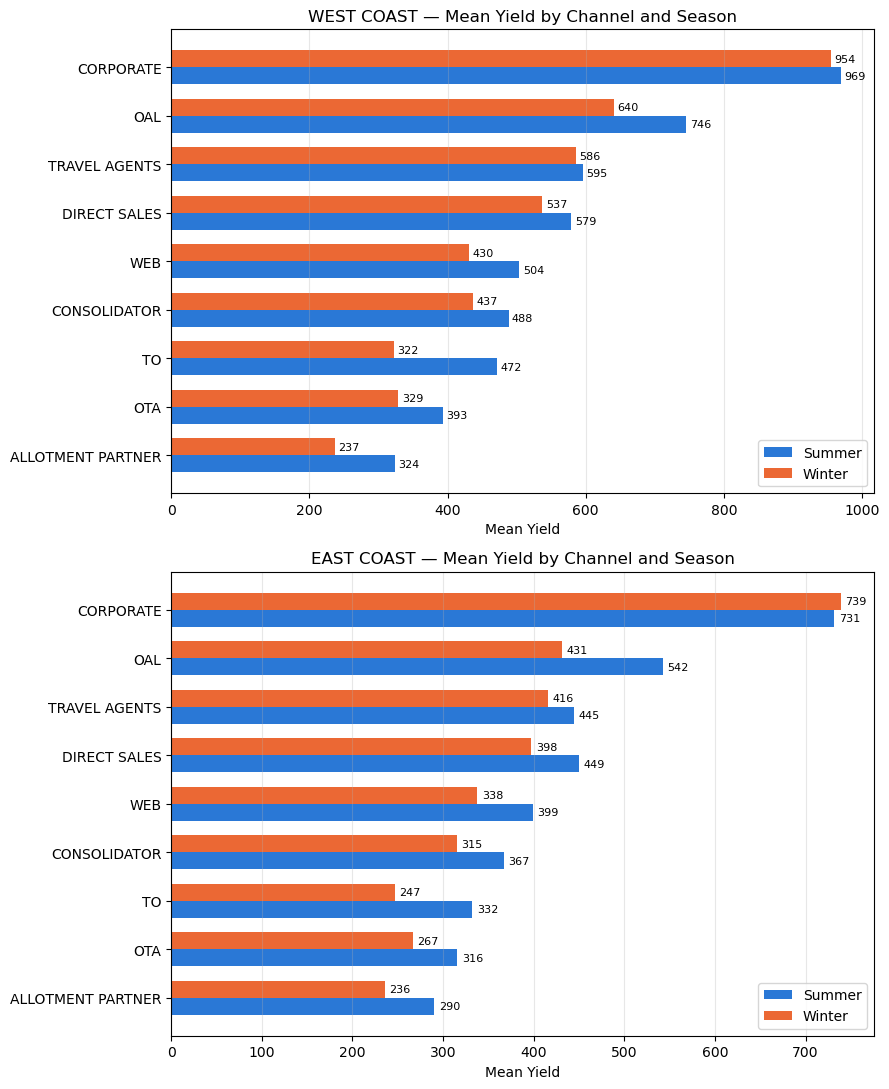


===== Mean Yield by Channel, Coast, and Season =====


In [57]:
# 4.3.1 Part B:  Yield Descriptive Statistics Table (by Route x Channel x Season)
yield_desc = booking_longhaul.groupby(
    ['TourDestination', 'Sales_Upper_Channel', 'Season_Type'], as_index=False
).agg(
    Mean_Yield=('Yield', 'mean'),
    Std_Yield=('Yield', 'std'),
    N_Bookings=('Bkd', 'count')
).sort_values('N_Bookings', ascending=False)

print("\n Yield Descriptive Statistics (Route x Channel x Season) ")
display(yield_desc.round(2))

#  4.3.1 Part C:  Yield Descriptive Statistics (Route x Channel x Season)  
import matplotlib.pyplot as plt
import numpy as np

channels_order = ['CORPORATE', 'OAL', 'TRAVEL AGENTS', 'DIRECT SALES',
                   'WEB', 'CONSOLIDATOR', 'TO', 'OTA', 'ALLOTMENT PARTNER']

def plot_yield_by_channel(df, dest, ax):
    sub = df[df['TourDestination'] == dest].set_index(
        ['Sales_Upper_Channel', 'Season_Type']
    )['Mean_Yield']

    summer = [sub.get((c, 'Summer'), np.nan) for c in channels_order]
    winter = [sub.get((c, 'Winter'), np.nan) for c in channels_order]

    y = np.arange(len(channels_order))
    height = 0.35

    ax.barh(y + height/2, summer, height=height, label='Summer', color='#2a78d6')
    ax.barh(y - height/2, winter, height=height, label='Winter', color='#eb6834')

    ax.set_yticks(y)
    ax.set_yticklabels(channels_order)
    ax.invert_yaxis() 
    ax.set_xlabel('Mean Yield')
    ax.set_title(f'{dest} — Mean Yield by Channel and Season')
    ax.legend()
    ax.grid(axis='x', alpha=0.3)


    for i, v in enumerate(summer):
        if not np.isnan(v):
            ax.text(v + 5, i + height/2, f'{v:.0f}', va='center', fontsize=8)
    for i, v in enumerate(winter):
        if not np.isnan(v):
            ax.text(v + 5, i - height/2, f'{v:.0f}', va='center', fontsize=8)

fig, axes = plt.subplots(2, 1, figsize=(9, 11))
plot_yield_by_channel(yield_desc, 'WEST COAST', axes[0])
plot_yield_by_channel(yield_desc, 'EAST COAST', axes[1])

plt.tight_layout()
plt.savefig('yield_by_channel_season.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n===== Mean Yield by Channel, Coast, and Season =====")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 60, Finished, Available, Finished, False)

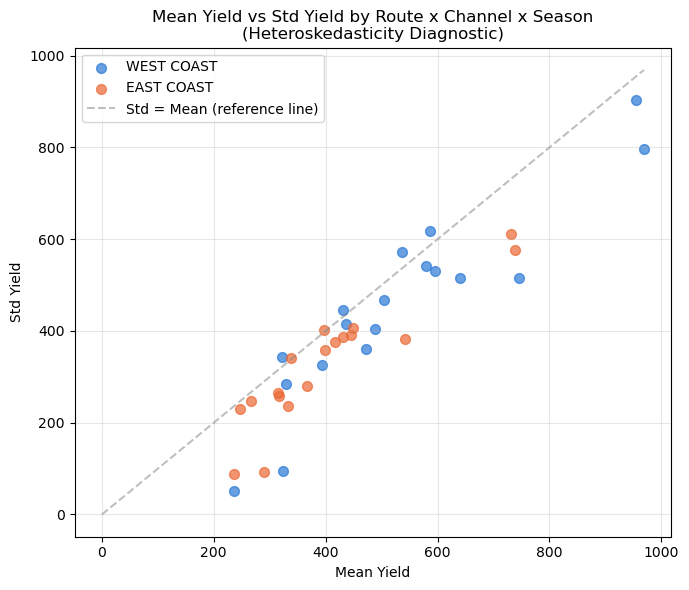


=====  Mean Yield vs Std Yield Scatter (Heteroskedasticity Check) =====

 Pearson correlation coefficient between Mean_Yield and Std_Yield: r = 0.9234


In [58]:
#  Mean_Yield vs Std_Yield 
fig, ax = plt.subplots(figsize=(7, 6))

colors = {'WEST COAST': '#2a78d6', 'EAST COAST': '#eb6834'}
for coast in ['WEST COAST', 'EAST COAST']:
    sub = yield_desc[yield_desc['TourDestination'] == coast]
    ax.scatter(sub['Mean_Yield'], sub['Std_Yield'],
               label=coast, color=colors[coast], alpha=0.7, s=50)

max_val = max(yield_desc['Mean_Yield'].max(), yield_desc['Std_Yield'].max())
ax.plot([0, max_val], [0, max_val], linestyle='--', color='gray',
        alpha=0.5, label='Std = Mean (reference line)')

ax.set_xlabel('Mean Yield')
ax.set_ylabel('Std Yield')
ax.set_title('Mean Yield vs Std Yield by Route x Channel x Season\n(Heteroskedasticity Diagnostic)')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('figure4_9_mean_std_yield_scatter.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=====  Mean Yield vs Std Yield Scatter (Heteroskedasticity Check) =====")

corr = yield_desc['Mean_Yield'].corr(yield_desc['Std_Yield'])
print(f"\n Pearson correlation coefficient between Mean_Yield and Std_Yield: r = {corr:.4f}")

In [59]:
# 4.3.2 Part C: CV(Yield) vs CV(SLF) 
yield_by_period = booking_longhaul.groupby(['TBY', 'Season_Type'], as_index=False).agg(
    Mean_Yield=('Yield', 'mean'),
    Std_Yield=('Yield', 'std')
)
yield_by_period['CV_Yield'] = yield_by_period['Std_Yield'] / yield_by_period['Mean_Yield']

slf_by_period = flight_level.groupby(['TBY', 'Season_Type'], as_index=False).agg(
    Mean_SLF=('flight_SLF', 'mean'),
    Std_SLF=('flight_SLF', 'std')
)
slf_by_period['CV_SLF'] = slf_by_period['Std_SLF'] / slf_by_period['Mean_SLF']

cv_compare = yield_by_period.merge(slf_by_period, on=['TBY', 'Season_Type'])[
    ['TBY', 'Season_Type', 'CV_Yield', 'CV_SLF']
]
print("\n Seasonal Volatility Comparison - CV(Yield) vs CV(SLF) ")
display(cv_compare.round(4))

cv_yield_of_means = yield_by_period['Mean_Yield'].std() / yield_by_period['Mean_Yield'].mean()
cv_slf_of_means = slf_by_period['Mean_SLF'].std() / slf_by_period['Mean_SLF'].mean()

print(f"\nCoefficient of variation of the across-period mean series: CV(Yield mean series) = {cv_yield_of_means:.4f}, "
      f"CV(SLF mean series) = {cv_slf_of_means:.4f}")
print(f"Ratio CV(Yield)/CV(SLF) = {cv_yield_of_means/cv_slf_of_means:.2f} -- "
      f"{'Supports' if cv_yield_of_means > cv_slf_of_means else 'Does not support'} "
      f"the Merkert & Webber (2018) hypothesis (seasonal fluctuation magnitude of yield is greater than that of SLF)")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 61, Finished, Available, Finished, False)


 Seasonal Volatility Comparison - CV(Yield) vs CV(SLF) 


SynapseWidget(Synapse.DataFrame, 16c7fea8-af9a-4494-b22a-1a27f1d0b89f)


Coefficient of variation of the across-period mean series: CV(Yield mean series) = 0.1269, CV(SLF mean series) = 0.0424
Ratio CV(Yield)/CV(SLF) = 2.99 -- Supports the Merkert & Webber (2018) hypothesis (seasonal fluctuation magnitude of yield is greater than that of SLF)


In [60]:
# ===== 4.3.4 Part D: Identify New Routes (Long-Haul Destinations with No Data in the Baseline Period) =====
baseline_vol_check = flight_level[flight_level['Phase'] == 'Baseline'].groupby(
    'TourDest_Airport', as_index=False
).agg(Baseline_N_Flights=('Core_Flight_Offer_id', 'nunique'))

all_dest = flight_level[['TourDest_Airport']].drop_duplicates()
baseline_vol_check = all_dest.merge(baseline_vol_check, on='TourDest_Airport', how='left')
baseline_vol_check['Baseline_N_Flights'] = baseline_vol_check['Baseline_N_Flights'].fillna(0)

NEW_ROUTES = baseline_vol_check.loc[
    baseline_vol_check['Baseline_N_Flights'] == 0, 'TourDest_Airport'
].tolist()

print(f"\nIdentified as newly launched long-haul destinations in 2025 (no flight records in the Baseline period): "
      f"{NEW_ROUTES if NEW_ROUTES else 'None -- all long-haul destinations have data in the Baseline period'}")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 62, Finished, Available, Finished, False)


Identified as newly launched long-haul destinations in 2025 (no flight records in the Baseline period): None -- all long-haul destinations have data in the Baseline period


In [61]:
# Part E (Panel Regression) can be run directly, without needing to exclude any routes:
panel_data = booking_longhaul[~booking_longhaul['TourDest_Airport'].isin(NEW_ROUTES)].copy()

panel_data['Self_Op'] = (panel_data['Phase'] == 'Post').astype(int)
panel_data['log_Yield'] = np.log(panel_data['Yield'])

panel_model = smf.ols(
    formula="log_Yield ~ Self_Op + C(Season_Type) + C(TourDest_Airport) + C(Sales_Upper_Channel)",
    data=panel_data
).fit(cov_type='cluster', cov_kwds={'groups': panel_data['TourDest_Airport']})

key_vars = ['Intercept', 'Self_Op'] + [v for v in panel_model.params.index if 'Season_Type' in v]
panel_result_table = pd.DataFrame({
    'Coefficient': panel_model.params, 'Std_Error': panel_model.bse, 'p_value': panel_model.pvalues
}).round(4)
panel_result_table.index.name = 'Variable'
panel_result_key = panel_result_table.loc[key_vars].reset_index()

print("\n=====Panel Fixed-Effects Regression Results =====")
display(panel_result_key)
print(f"\nR² = {panel_model.rsquared:.4f}, N = {int(panel_model.nobs)}")

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 63, Finished, Available, Finished, False)

2026-07-24:02:18:49,757 ERROR    [shared_platform_utils.py:82] Create MLExperiment failed, status_code: 403, b'{"requestId":"7fa35aa5-0f69-4fcb-88e4-f2368b8b2f7c","errorCode":"FeatureNotAvailable","message":"The feature is not available","isRetriable":false}'
2026-07-24:02:18:49,760 ERROR    [synapse_mlflow_utils.py:390] [fabric mlflow plugin]: <class 'synapse.ml.mlflow.tracking_store.TridentMLflowTrackingStore'>.create_experiment exception 'NoneType' object has no attribute 'properties'
2026-07-24:02:18:49,762 ERROR    [default_experiment_registry.py:55] Error find or created notebook/SJD default experiment, please call mlflow.set_experiment to set a valid one before run
Traceback (most recent call last):
  File "/home/trusted-service-user/cluster-env/trident_env/lib/python3.11/site-packages/synapse/ml/mlflow/default_experiment_registry.py", line 52, in get_experiment_id
    return mlflow.set_experiment(f"{artifact_name}").experiment_id
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^


=====Panel Fixed-Effects Regression Results =====


SynapseWidget(Synapse.DataFrame, 91cc2707-3b3a-40d4-8dc1-742b4eec9b49)


R² = 0.1127, N = 1480121


In [62]:
#Descriptive Performance of New Branch Line Routes (Short Haul) Yield/SLF 
shorthaul_yield = df_shorthaul.merge(
    df_shorthaul_flights[['Core_Flight_Offer_id', 'TBY', 'Season_Type', 'Phase']],
    on='Core_Flight_Offer_id', how='inner'
)
shorthaul_yield = shorthaul_yield[shorthaul_yield['Bkd'] > 0].copy()
shorthaul_yield['Yield'] = np.where(
    shorthaul_yield['Bkd'] > 0, shorthaul_yield['BkdRev_final'] / shorthaul_yield['Bkd'], np.nan
)
shorthaul_yield = shorthaul_yield[shorthaul_yield['Yield'].notna() & (shorthaul_yield['Yield'] > 0)]

shorthaul_post = shorthaul_yield[shorthaul_yield['Phase'] == 'Post']

new_route_summary = shorthaul_post.groupby('Dest_Airport', as_index=False).agg(
    Mean_Yield=('Yield', 'mean'),
    Std_Yield=('Yield', 'std'),
    N_Bookings=('Bkd', 'count')
)

print("\n Yield Descriptive Statistics for New Branch Routes(after 2025 seldf-operation) ")
display(new_route_summary.round(3))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 64, Finished, Available, Finished, False)


 Yield Descriptive Statistics for New Branch Routes(after 2025 seldf-operation) 


SynapseWidget(Synapse.DataFrame, bb5c8156-66fb-4851-a101-5a5579fab5df)

In [64]:
# Part F  New Branch Route Lines (8 Self-operated Branch Cities) Yield + SLF Descriptive Statistics

# Yield
shorthaul_yield = df_shorthaul.merge(
    df_shorthaul_flights[['Core_Flight_Offer_id', 'TBY', 'Season_Type', 'Phase']],
    on='Core_Flight_Offer_id', how='inner'
)
shorthaul_yield = shorthaul_yield[shorthaul_yield['Bkd'] > 0].copy()
shorthaul_yield['Yield'] = np.where(
    shorthaul_yield['Bkd'] > 0, shorthaul_yield['BkdRev_final'] / shorthaul_yield['Bkd'], np.nan
)
shorthaul_yield = shorthaul_yield[shorthaul_yield['Yield'].notna() & (shorthaul_yield['Yield'] > 0)]

shorthaul_post = shorthaul_yield[shorthaul_yield['Phase'] == 'Post']

shorthaul_post = shorthaul_post[shorthaul_post['Dest_Airport'].isin(SELF_OP_FEEDER_CITIES)]
assert shorthaul_post.shape[0] > 0, "After filtering, the result is empty - Please check if SELF_OP_FEEDER_CITIES is consistent with the definition of Dest_Airport"
new_route_yield_summary = shorthaul_post.groupby('Dest_Airport', as_index=False).agg(
    Mean_Yield=('Yield', 'mean'),
    Std_Yield=('Yield', 'std'),
    N_Bookings=('Bkd', 'count')
)

#  SLF
new_route_slf_summary = df_shorthaul_flights[
    (df_shorthaul_flights['Phase'] == 'Post') &
    (df_shorthaul_flights['Dest_Airport'].isin(SELF_OP_FEEDER_CITIES))
].groupby('Dest_Airport', as_index=False).agg(
    Mean_SLF=('flight_SLF', 'mean'),
    Std_SLF=('flight_SLF', 'std'),
    N_Flights=('Core_Flight_Offer_id', 'nunique')
)

new_route_summary = new_route_yield_summary.merge(
    new_route_slf_summary, on='Dest_Airport', how='outer'
).sort_values('N_Bookings', ascending=False)

print("\nNew feeder routes (8 independently operated feeder cities) Yield + SLF Descriptive Statistics")
display(new_route_summary.round(3))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 67, Finished, Available, Finished, False)


New feeder routes (8 independently operated feeder cities) Yield + SLF Descriptive Statistics


SynapseWidget(Synapse.DataFrame, f67d66d8-20aa-4dd6-9bb3-0b5364feee5b)

# 4.4 Channel Differentiated Seat Allocation Framework

In [65]:
# ===== 4.4 Part A: 9-Channel x Season x TBY BKD%/REV% Share Tables =====

def build_share_pivot(df, value_col, season):
    """
    df: channel_tby
    value_col: 'Bkd_Share' or 'Revenue_Share'
    season: 'Summer' or 'Winter'
    Returns: rows = TBY, columns = 9 channels, values = share (%)
    """
    sub = df[df['Season_Type'] == season].copy()
    pivot = sub.pivot_table(
        index='TBY', columns='Sales_Upper_Channel', values=value_col, aggfunc='first'
    ).round(4) * 100  # convert to percentage
    pivot.columns.name = None
    pivot = pivot.reset_index()
    return pivot

bkd_share_summer = build_share_pivot(channel_tby, 'Bkd_Share', 'Summer')
bkd_share_winter = build_share_pivot(channel_tby, 'Bkd_Share', 'Winter')
rev_share_summer = build_share_pivot(channel_tby, 'Revenue_Share', 'Summer')
rev_share_winter = build_share_pivot(channel_tby, 'Revenue_Share', 'Winter')

print("\n=====  BKD Share by Channel - Summer (%) =====")
display(bkd_share_summer.round(2))
print("\n=====  BKD Share by Channel - Winter (%) =====")
display(bkd_share_winter.round(2))
print("\n===== Revenue Share by Channel - Summer (%) =====")
display(rev_share_summer.round(2))
print("\n===== Revenue Share by Channel - Winter (%) =====")
display(rev_share_winter.round(2))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 68, Finished, Available, Finished, False)


=====  BKD Share by Channel - Summer (%) =====


SynapseWidget(Synapse.DataFrame, 3c42c438-57f2-4f23-b2d4-13dd956d1929)


=====  BKD Share by Channel - Winter (%) =====


SynapseWidget(Synapse.DataFrame, 280f4834-0d80-42fa-98c9-f008bd191349)


===== Revenue Share by Channel - Summer (%) =====


SynapseWidget(Synapse.DataFrame, 97da9234-a324-4d6b-bb60-705408551c92)


===== Revenue Share by Channel - Winter (%) =====


SynapseWidget(Synapse.DataFrame, f2fa14e6-a10f-424f-b435-4e2b496202d3)

In [66]:
#4.4 Part A2: Calculate the cross-TBY average for each of the 4 share tables according to the channel, and then integrate them into a single summary table
def average_across_tby(pivot_df):
    """
    Calculate the cross-TBY average for each channel based on pivot_df (with rows as TBY and columns as channels)
Return: Series, index = channel names, values = averages
    """
    numeric_cols = [c for c in pivot_df.columns if c != 'TBY']
    return pivot_df[numeric_cols].mean().round(2)

bkd_summer_avg = average_across_tby(bkd_share_summer)
bkd_winter_avg = average_across_tby(bkd_share_winter)
rev_summer_avg = average_across_tby(rev_share_summer)
rev_winter_avg = average_across_tby(rev_share_winter)

# ===== SummerBKD%、Rev% =====
channel_share_summary_summer = pd.DataFrame({
    'BKD_Share_%': bkd_summer_avg,
    'Revenue_Share_%': rev_summer_avg
}).reset_index().rename(columns={'index': 'Sales_Upper_Channel'})

# ===== WinterBKD%、Rev% =====
channel_share_summary_winter = pd.DataFrame({
    'BKD_Share_%': bkd_winter_avg,
    'Revenue_Share_%': rev_winter_avg
}).reset_index().rename(columns={'index': 'Sales_Upper_Channel'})

print("\n=====  Channel Share Summary - Summer (Averaged Across TBY) =====")
display(channel_share_summary_summer.round(2))
print("\n===== Channel Share Summary - Winter (Averaged Across TBY) =====")
display(channel_share_summary_winter.round(2))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 69, Finished, Available, Finished, False)


=====  Channel Share Summary - Summer (Averaged Across TBY) =====


SynapseWidget(Synapse.DataFrame, 377e8cbb-bba4-4ffb-8cbe-2d8fe0c84ba5)


===== Channel Share Summary - Winter (Averaged Across TBY) =====


SynapseWidget(Synapse.DataFrame, b89ef129-3a3f-4906-9159-1ab45919f4f7)

In [67]:
# ===== 4.4 Part A3: 补充Dimension 1打分(用表4-15的均值数据) =====

def score_business_scale(share_pct):
    """share_pct: 百分比数值, 如25代表25%"""
    if share_pct >= 10:
        return 4
    elif share_pct >= 7:
        return 3
    elif share_pct >= 4:
        return 2
    elif share_pct >= 1:
        return 1
    else:
        return 0

channel_share_summary_summer['Score_D1_BKD'] = channel_share_summary_summer['BKD_Share_%'].apply(score_business_scale)
channel_share_summary_summer['Score_D1_Rev'] = channel_share_summary_summer['Revenue_Share_%'].apply(score_business_scale)

channel_share_summary_winter['Score_D1_BKD'] = channel_share_summary_winter['BKD_Share_%'].apply(score_business_scale)
channel_share_summary_winter['Score_D1_Rev'] = channel_share_summary_winter['Revenue_Share_%'].apply(score_business_scale)

print("\n=====  Dimension 1 - Summer =====")
display(channel_share_summary_summer)
print("\n=====  Dimension 1 - Winter =====")
display(channel_share_summary_winter)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 70, Finished, Available, Finished, False)


===== Table 4-15a (with Score): Dimension 1 - Summer =====


SynapseWidget(Synapse.DataFrame, 7832259e-4952-4710-83a1-3d7a9a8d90db)


===== Table 4-15b (with Score): Dimension 1 - Winter =====


SynapseWidget(Synapse.DataFrame, bd32c417-f50a-4081-913a-e56e201c6f3a)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 71, Finished, Available, Finished, False)

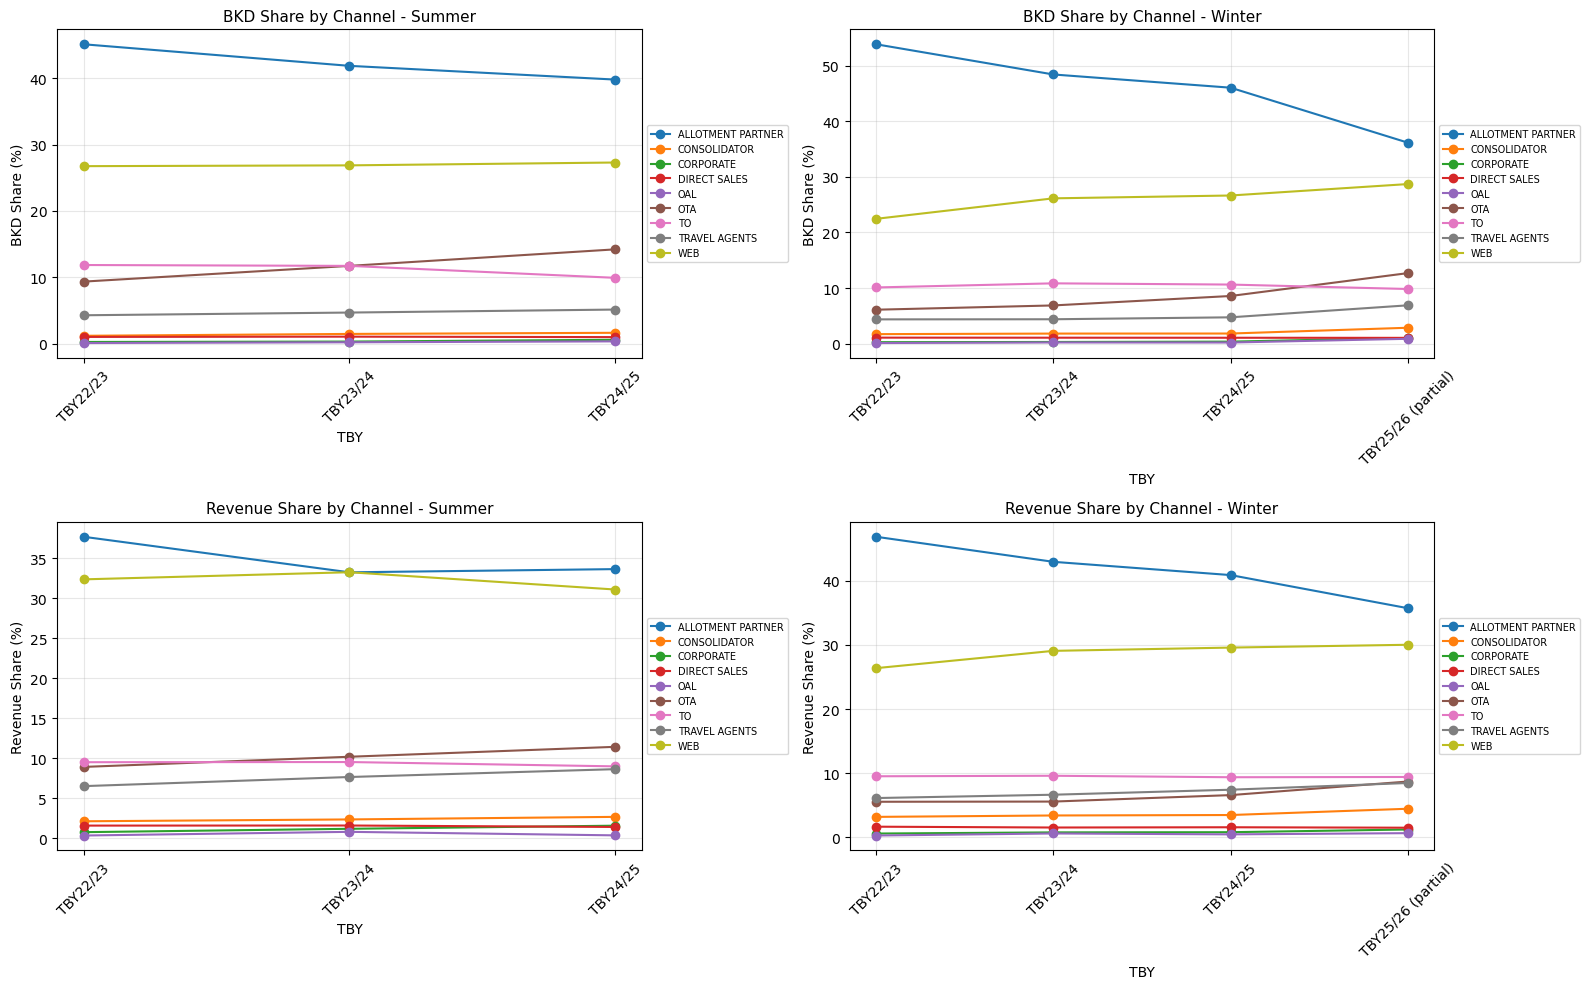


===== Figure 4-x: Channel BKD%/Revenue% Share Trend Across TBY (by Season) =====


In [68]:
# ===== 4.4 Part B: Channel Share Trend Across TBY (split by season) =====
import matplotlib.pyplot as plt

def plot_channel_trend(pivot_df, title, ylabel, ax):
    for ch in pivot_df.columns:
        if ch == 'TBY':
            continue
        ax.plot(pivot_df['TBY'], pivot_df[ch], marker='o', label=ch, linewidth=1.5)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('TBY')
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45)
    ax.legend(fontsize=7, loc='center left', bbox_to_anchor=(1.0, 0.5))
    ax.grid(alpha=0.3)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plot_channel_trend(bkd_share_summer, 'BKD Share by Channel - Summer', 'BKD Share (%)', axes[0, 0])
plot_channel_trend(bkd_share_winter, 'BKD Share by Channel - Winter', 'BKD Share (%)', axes[0, 1])
plot_channel_trend(rev_share_summer, 'Revenue Share by Channel - Summer', 'Revenue Share (%)', axes[1, 0])
plot_channel_trend(rev_share_winter, 'Revenue Share by Channel - Winter', 'Revenue Share (%)', axes[1, 1])

plt.tight_layout()
plt.savefig('figure4_x_channel_share_trend.png', dpi=200, bbox_inches='tight')
plt.show()

print("\n=====  Channel BKD%/Revenue% Share Trend Across TBY (by Season) =====")

In [69]:
## ===== 4.4 Part B2: Auto-classify BKD%/Rev% trend across TBY for each channel,
#      based on the raw data from Table 4-12/4-13 =====

def classify_trend(values, min_change_ratio=0.08, min_change_abs=1.0):
    """
    Classify a channel's share trend across TBY periods and assign a score.
    First applies an amplitude check (whether the range reaches 8% of the channel's
    own mean, or 1 percentage point, whichever is larger) to avoid noise-level
    fluctuations being misclassified as a real trend.

    values: list or array, values ordered by TBY sequence (percentage values, e.g. 26.8 = 26.8%)
    Returns: (trend_type, score)
    """
    v = np.array(values, dtype=float)
    n = len(v)
    if n < 2:
        return "Insufficient data", None

    amplitude = v.max() - v.min()
    threshold = max(v.mean() * min_change_ratio, min_change_abs)
    if amplitude < threshold:
        return "Stable fluctuation", 3

    diffs = np.diff(v)

    if np.all(diffs > 0):
        return "Continuous increase", 6
    if np.all(diffs < 0):
        return "Continuous decrease", 1

    min_idx = np.argmin(v)
    max_idx = np.argmax(v)

    if 0 < min_idx < n - 1:
        before = v[:min_idx + 1]
        after = v[min_idx:]
        if np.all(np.diff(before) <= 0) and np.all(np.diff(after) >= 0):
            return "U-shaped recovery (decline then increase)", 4

    if 0 < max_idx < n - 1:
        before = v[:max_idx + 1]
        after = v[max_idx:]
        if np.all(np.diff(before) >= 0) and np.all(np.diff(after) <= 0):
            return "Inverted U-shaped peak (increase then decline)", 2

    x = np.arange(n)
    slope = np.polyfit(x, v, 1)[0]

    if slope > 0:
        return "Overall upward trend", 5
    else:
        return "Stable fluctuation", 3


def build_trend_score_table(pivot_df, table_name):
    """
    pivot_df: output of build_share_pivot (rows = TBY, columns = 9 channels)
    For each channel, output: start value, end value, net change (pp),
    amplitude (pp), trend type, and score.
    """
    channels = [c for c in pivot_df.columns if c != 'TBY']
    records = []
    for ch in channels:
        values = pivot_df[ch].tolist()
        trend_type, score = classify_trend(values)
        records.append({
            'Sales_Upper_Channel': ch,
            'Start_Value_%': round(values[0], 2),
            'End_Value_%': round(values[-1], 2),
            'Net_Change_pp': round(values[-1] - values[0], 2),
            'Amplitude_pp': round(max(values) - min(values), 2),
            'Trend_Type': trend_type,
            'Score': score
        })
    result = pd.DataFrame(records).sort_values('Score', ascending=False)
    print(f"\n===== Table: Channel Trend Classification - {table_name} =====")
    display(result)
    return result

trend_bkd_summer = build_trend_score_table(bkd_share_summer, 'BKD Share - Summer')
trend_bkd_winter = build_trend_score_table(bkd_share_winter, 'BKD Share - Winter')
trend_rev_summer = build_trend_score_table(rev_share_summer, 'Revenue Share - Summer')
trend_rev_winter = build_trend_score_table(rev_share_winter, 'Revenue Share - Winter')

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 72, Finished, Available, Finished, False)


===== Table: Channel Trend Classification - BKD Share - Summer =====


SynapseWidget(Synapse.DataFrame, 1e304da7-07fd-4763-96a3-baa83710b558)


===== Table: Channel Trend Classification - BKD Share - Winter =====


SynapseWidget(Synapse.DataFrame, ad7bead3-a121-4b2a-9df7-d12981fd1d94)


===== Table: Channel Trend Classification - Revenue Share - Summer =====


SynapseWidget(Synapse.DataFrame, 9b691da0-80d5-4964-93c5-2b3fb39217a4)


===== Table: Channel Trend Classification - Revenue Share - Winter =====


SynapseWidget(Synapse.DataFrame, 5fa4ac67-e90c-436a-90ec-d813d1cc6ade)

In [70]:
# ===== 4.4 Part B3: Merge BKD and Revenue trend classification results into
def merge_bkd_rev_trend(bkd_trend_df, rev_trend_df, season_label):
    """
    bkd_trend_df: BKD trend classification table for the season (contains Trend_Type, Score)
    rev_trend_df: Revenue trend classification table for the season (contains Trend_Type, Score)
    Returns: merged table, one row per channel, with BKD and Revenue Trend_Type/Score side by side
    """
    bkd_sub = bkd_trend_df[['Sales_Upper_Channel', 'Trend_Type', 'Score']].rename(
        columns={'Trend_Type': 'BKD_Trend_Type', 'Score': 'BKD_Score'}
    )
    rev_sub = rev_trend_df[['Sales_Upper_Channel', 'Trend_Type', 'Score']].rename(
        columns={'Trend_Type': 'Rev_Trend_Type', 'Score': 'Rev_Score'}
    )
    merged = bkd_sub.merge(rev_sub, on='Sales_Upper_Channel', how='outer')
    print(f"\n===== Table: BKD & Revenue Trend Classification Summary - {season_label} =====")
    display(merged)
    return merged

trend_summary_summer = merge_bkd_rev_trend(trend_bkd_summer, trend_rev_summer, 'Summer')
trend_summary_winter = merge_bkd_rev_trend(trend_bkd_winter, trend_rev_winter, 'Winter')

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 73, Finished, Available, Finished, False)


===== Table: BKD & Revenue Trend Classification Summary - Summer =====


SynapseWidget(Synapse.DataFrame, c9d12a28-8cc2-4884-9d89-d2b55e21a2ad)


===== Table: BKD & Revenue Trend Classification Summary - Winter =====


SynapseWidget(Synapse.DataFrame, 5b48b8ee-f316-442f-b536-aa8e5955be44)

In [75]:
# ===== 4.4 Part C: 9-Channel x Season x TBY Yield Table =====
yield_by_channel_season_tby = drill_4dim_final.groupby(
    ['TBY', 'Season_Type', 'Sales_Upper_Channel'], as_index=False
).agg(
    Sum_Bkd=('Sum_Bkd', 'sum'),
    Sum_Revenue=('Sum_Revenue', 'sum')
)
yield_by_channel_season_tby['Yield'] = np.where(
    yield_by_channel_season_tby['Sum_Bkd'] > 0,
    yield_by_channel_season_tby['Sum_Revenue'] / yield_by_channel_season_tby['Sum_Bkd'],
    np.nan
)
yield_by_channel_season_tby['Yield'] = yield_by_channel_season_tby['Yield'].round(2)

def build_yield_pivot(df, season):
    sub = df[df['Season_Type'] == season].copy()
    pivot = sub.pivot_table(index='TBY', columns='Sales_Upper_Channel', values='Yield', aggfunc='first')
    pivot.columns.name = None
    pivot = pivot.reset_index()
    return pivot

yield_pivot_summer = build_yield_pivot(yield_by_channel_season_tby, 'Summer')
yield_pivot_winter = build_yield_pivot(yield_by_channel_season_tby, 'Winter')

print("\n===== Yield by Channel - Summer =====")
display(yield_pivot_summer.round(2))
print("\n=====  Yield by Channel - Winter =====")
display(yield_pivot_winter.round(2))

# Mean yield across TBY periods (input for Dimension 3 scoring in Section 4.4)
yield_avg_by_channel_season = yield_by_channel_season_tby.groupby(
    ['Season_Type', 'Sales_Upper_Channel'], as_index=False
).agg(Mean_Yield=('Yield', 'mean')).round(2)

print("\n===== Mean Yield Across TBY Periods (by Channel x Season, for Section 4.4 scoring) =====")
display(yield_avg_by_channel_season)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 81, Finished, Available, Finished, False)


===== Yield by Channel - Summer =====


SynapseWidget(Synapse.DataFrame, b6a53c5c-e8d2-4e1d-8b96-a9cb7842fd9e)


=====  Yield by Channel - Winter =====


SynapseWidget(Synapse.DataFrame, bec45609-ed44-4693-8c79-cade12199ab4)


===== Mean Yield Across TBY Periods (by Channel x Season, for Section 4.4 scoring) =====


SynapseWidget(Synapse.DataFrame, 708c71cd-8f42-44ac-9762-6a93830dcfdb)

In [72]:
# ===== 4.4 Part D: Dimension 4 - 3-Year Average BKD Seasonal Share per Channel
#      (Business Concentration Risk) =====
FULL_TBY_3YR = ['TBY22/23', 'TBY23/24', 'TBY24/25']

def build_concentration_input(df, season):
    """
    df: channel_tby
    season: 'Summer' or 'Winter'
    Returns: mean BKD_Share (%) for each channel across the 3 full TBY years
    """
    sub = df[
        (df['Season_Type'] == season) & (df['TBY'].isin(FULL_TBY_3YR))
    ].copy()
    result = sub.groupby('Sales_Upper_Channel', as_index=False).agg(
        BKD_Share_3yr_Avg_pct=('Bkd_Share', 'mean')
    )
    result['BKD_Share_3yr_Avg_pct'] = (result['BKD_Share_3yr_Avg_pct'] * 100).round(2)
    return result

concentration_summer = build_concentration_input(channel_tby, 'Summer')
concentration_winter = build_concentration_input(channel_tby, 'Winter')

print("\n=====  3-Year Average BKD Seasonal Share - Summer (%) =====")
display(concentration_summer.sort_values('BKD_Share_3yr_Avg_pct', ascending=False))
print("\n=====-Year Average BKD Seasonal Share - Winter (%) =====")
display(concentration_winter.sort_values('BKD_Share_3yr_Avg_pct', ascending=False))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 75, Finished, Available, Finished, False)


=====  3-Year Average BKD Seasonal Share - Summer (%) =====


SynapseWidget(Synapse.DataFrame, 31da7d43-050a-4c1c-a75f-4a784dfe7b95)


=====-Year Average BKD Seasonal Share - Winter (%) =====


SynapseWidget(Synapse.DataFrame, ed1a386c-6903-4cce-a5a6-4c4a0a2caadb)

In [76]:
# ===== 4.4 Part D2: Score Dimension 4 based on the scoring criteria
#      (>=30% -> -2, 5-30% -> -1, <5% -> 0) =====

def score_concentration_risk(share_3yr_avg_pct):
    """share_3yr_avg_pct: 3-year average BKD seasonal share (%)"""
    if share_3yr_avg_pct >= 30:
        return -2
    elif share_3yr_avg_pct >= 5:
        return -1
    else:
        return 0

concentration_summer['Score_D4'] = concentration_summer['BKD_Share_3yr_Avg_pct'].apply(score_concentration_risk)
concentration_winter['Score_D4'] = concentration_winter['BKD_Share_3yr_Avg_pct'].apply(score_concentration_risk)

print("\n=====  Dimension 4 - Summer =====")
display(concentration_summer.sort_values('Score_D4'))
print("\n=====  Dimension 4 - Winter =====")
display(concentration_winter.sort_values('Score_D4'))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 83, Finished, Available, Finished, False)


=====  Dimension 4 - Summer =====


SynapseWidget(Synapse.DataFrame, 4764b752-15b5-4f02-8d92-c061179907ce)


=====  Dimension 4 - Winter =====


SynapseWidget(Synapse.DataFrame, f5c0e638-91d4-4a47-bc37-74b2487b0727)

In [77]:
# ===== 4.4 Part E (Scores Only): Consolidate the 4-dimension scores into
#      one master table per season, without raw values =====

def build_master_score_table(season):
    """
    Consolidate Dimension 1-4 scores only into one table, by season
    season: 'Summer' or 'Winter'
    """
    if season == 'Summer':
        d1 = channel_share_summary_summer.copy()
        trend_bkd = trend_bkd_summer.copy()
        trend_rev = trend_rev_summer.copy()
        conc = concentration_summer.copy()
    else:
        d1 = channel_share_summary_winter.copy()
        trend_bkd = trend_bkd_winter.copy()
        trend_rev = trend_rev_winter.copy()
        conc = concentration_winter.copy()

    yield_sub = yield_avg_by_channel_season[
        yield_avg_by_channel_season['Season_Type'] == season
    ][['Sales_Upper_Channel', 'Mean_Yield']].copy()

    # Dimension 3 score: percentile rank among the 9 channels in this season
    ranks = yield_sub['Mean_Yield'].rank(pct=True)
    yield_sub['Score_D3'] = pd.cut(
        ranks, bins=[0, 0.5, 0.8, 1.0], labels=[1, 3, 6], include_lowest=True
    ).astype(int)

    master = d1[['Sales_Upper_Channel', 'Score_D1_BKD', 'Score_D1_Rev']].copy()

    master = master.merge(
        trend_bkd[['Sales_Upper_Channel', 'Score']].rename(columns={'Score': 'Score_D2_BKD'}),
        on='Sales_Upper_Channel', how='left'
    )
    master = master.merge(
        trend_rev[['Sales_Upper_Channel', 'Score']].rename(columns={'Score': 'Score_D2_Rev'}),
        on='Sales_Upper_Channel', how='left'
    )
    master = master.merge(
        yield_sub[['Sales_Upper_Channel', 'Score_D3']], on='Sales_Upper_Channel', how='left'
    )
    master = master.merge(
        conc[['Sales_Upper_Channel', 'Score_D4']], on='Sales_Upper_Channel', how='left'
    )

    return master

master_summer = build_master_score_table('Summer')
master_winter = build_master_score_table('Winter')

print("\n=====  Four-Dimension Scores - Summer =====")
display(master_summer)
print("\n=====  Four-Dimension Scores - Winter =====")
display(master_winter)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 84, Finished, Available, Finished, False)


=====  Four-Dimension Scores - Summer =====


SynapseWidget(Synapse.DataFrame, 40f28488-6d24-4085-b87a-20aef0aa3f77)


=====  Four-Dimension Scores - Winter =====


SynapseWidget(Synapse.DataFrame, 98fd2545-79b5-4192-8c6c-b7cb2b9e9961)

In [78]:
def average_bkd_rev_scores(master_df):
    master_df = master_df.copy()
    master_df['Score_D1'] = master_df[['Score_D1_BKD', 'Score_D1_Rev']].mean(axis=1).round(2)
    master_df['Score_D2'] = master_df[['Score_D2_BKD', 'Score_D2_Rev']].mean(axis=1).round(2)

    result = master_df[[
        'Sales_Upper_Channel', 'Score_D1', 'Score_D2', 'Score_D3', 'Score_D4'
    ]]
    return result

master_summer_avg = average_bkd_rev_scores(master_summer)
master_winter_avg = average_bkd_rev_scores(master_winter)

print("\n=====  Four-Dimension Scores - Summer =====")
display(master_summer_avg)
print("\n=====  Four-Dimension Scores - Winter =====")
display(master_winter_avg)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 85, Finished, Available, Finished, False)


=====  Four-Dimension Scores - Summer =====


SynapseWidget(Synapse.DataFrame, a79f7c9e-0aca-4f4c-99be-58d39cdeeeb6)


=====  Four-Dimension Scores - Winter =====


SynapseWidget(Synapse.DataFrame, f00f747c-8c54-4de7-93f2-fc56dcb21087)

In [79]:
# ===== 4.4 Part F: Calculate the weighted comprehensive score based on the company's business experience weight. =====

WEIGHTS = {
    'D1': 0.3,
    'D2': 0.3,
    'D3': 0.4
}

def calc_weighted_total(master_avg_df):
    df = master_avg_df.copy()
    df['Weighted_Score'] = (
        df['Score_D1'] * WEIGHTS['D1'] +
        df['Score_D2'] * WEIGHTS['D2'] +
        df['Score_D3'] * WEIGHTS['D3']
    ).round(2)
    df['Weighted_Total'] = (df['Weighted_Score'] + df['Score_D4']).round(2)
    return df.sort_values('Weighted_Total', ascending=False)

summer_final = calc_weighted_total(master_summer_avg)
winter_final = calc_weighted_total(master_winter_avg)

print("\n=====  Weighted Composite Score - Summer (D1=0.3, D2=0.3, D3=0.4, D4 as deduction) =====")
display(summer_final)
print("\n=====  Weighted Composite Score - Winter (D1=0.3, D2=0.3, D3=0.4, D4 as deduction) =====")
display(winter_final)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 86, Finished, Available, Finished, False)


=====  Weighted Composite Score - Summer (D1=0.3, D2=0.3, D3=0.4, D4 as deduction) =====


SynapseWidget(Synapse.DataFrame, 5f94903d-c9ae-4b68-bb1b-94de766165b4)


=====  Weighted Composite Score - Winter (D1=0.3, D2=0.3, D3=0.4, D4 as deduction) =====


SynapseWidget(Synapse.DataFrame, b704a059-aa5f-4c25-97a9-218032b03bca)

In [ ]:
# ===== 4.4.4 Part A: Calculate the booking time distribution for each channel (NDO_Category proportion) =====
# The drill_4dim_final already contains the NDO_Category field (Early/Mid-term/Late bookers), and is summed up by the Sum_Bkd column. 
ndo_dist = drill_4dim_final.groupby(
['Sales_Upper_Channel', 'NDO_Category'], as_index=False
).agg(Bkd=('Sum_Bkd', 'sum'))

# Convert to the proportion within each channel (instead of the proportion for the entire company) ndo_dist['Channel_Total_Bkd'] = ndo_dist.groupby('Sales_Upper_Channel')['Bkd'].transform('sum')
ndo_dist['NDO_Share_%'] = (ndo_dist['Bkd'] / ndo_dist['Channel_Total_Bkd'] * 100).round(2)

ndo_pivot = ndo_dist.pivot_table(
index='Sales_Upper_Channel', columns='NDO_Category', values='NDO_Share_%', aggfunc='first'
).fillna(0)
ndo_pivot.columns.name = None
ndo_pivot = ndo_pivot.reset_index()

print("\n===== Table: Booking Timing Distribution by Channel (%) =====")
display(ndo_pivot)

ndo_pivot['Dominant_NDO'] = ndo_pivot[ndo_categories].idxmax(axis=1)

print("\n===== Table: Dominant Booking Timing by Channel =====")
display(ndo_pivot[['Sales_Upper_Channel', 'Dominant_NDO']])

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, -1, Cancelled, , Cancelled, True)

In [80]:
# ===== 4.4.4 Part B: Calculate the revenue level classification for each channel (High/Mid/Low, combined across seasons) =====


yield_overall = drill_4dim_final.groupby('Sales_Upper_Channel', as_index=False).agg(
    Sum_Bkd=('Sum_Bkd', 'sum'), Sum_Revenue=('Sum_Revenue', 'sum')
)
yield_overall['Mean_Yield'] = (yield_overall['Sum_Revenue'] / yield_overall['Sum_Bkd']).round(2)

def yield_tier(yield_series):
    ranks = yield_series.rank(pct=True)
    tier = pd.cut(
        ranks, bins=[0, 0.33, 0.67, 1.0], labels=['Low', 'Mid', 'High'], include_lowest=True
    )
    return tier

yield_overall['Yield_Tier'] = yield_tier(yield_overall['Mean_Yield'])

print("\n===== Table: Channel Yield Level and Tier =====")
display(yield_overall[['Sales_Upper_Channel', 'Mean_Yield', 'Yield_Tier']].sort_values('Mean_Yield', ascending=False))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 89, Finished, Available, Finished, False)


===== Table: Channel Yield Level and Tier =====


SynapseWidget(Synapse.DataFrame, 626c8cee-8a5c-4477-967b-7d6300d9f73d)

In [81]:
# ===== 4.4.4 Booking Timing x Yield Behavioral Classification =====
# Full pipeline: NDO distribution -> Yield level -> neutral quadrant positioning
# -> category-internal deviation check

# ---- Step 1: Booking timing distribution by channel (NDO_Category share) ----
ndo_dist = drill_4dim_final.groupby(
    ['Sales_Upper_Channel', 'NDO_Category'], as_index=False
).agg(Bkd=('Sum_Bkd', 'sum'))

ndo_dist['Channel_Total_Bkd'] = ndo_dist.groupby('Sales_Upper_Channel')['Bkd'].transform('sum')
ndo_dist['NDO_Share_%'] = (ndo_dist['Bkd'] / ndo_dist['Channel_Total_Bkd'] * 100).round(2)

late_share = ndo_dist[ndo_dist['NDO_Category'] == 'Late bookers'][
    ['Sales_Upper_Channel', 'NDO_Share_%']
].rename(columns={'NDO_Share_%': 'Late_Bookers_Share_%'})

# ---- Step 2: Overall yield level by channel (pooled across seasons) ----
yield_overall = drill_4dim_final.groupby('Sales_Upper_Channel', as_index=False).agg(
    Sum_Bkd=('Sum_Bkd', 'sum'), Sum_Revenue=('Sum_Revenue', 'sum')
)
yield_overall['Mean_Yield'] = (yield_overall['Sum_Revenue'] / yield_overall['Sum_Bkd']).round(2)

# ---- Step 3: Combine, attach the 3-category mapping from Section 4.1 ----
behavior_base = late_share.merge(
    yield_overall[['Sales_Upper_Channel', 'Mean_Yield']], on='Sales_Upper_Channel', how='left'
)

channel_map = {
    'WEB': 'Direct', 'DIRECT SALES': 'Direct',
    'TRAVEL AGENTS': 'Agent', 'OTA': 'Agent', 'CORPORATE': 'Agent',
    'ALLOTMENT PARTNER': 'Wholesale', 'TO': 'Wholesale', 'CONSOLIDATOR': 'Wholesale',
}
behavior_base['Channel_Category'] = behavior_base['Sales_Upper_Channel'].map(channel_map)
behavior_base = behavior_base[behavior_base['Channel_Category'].notna()].copy()
# Note: OAL is excluded, consistent with the 3-category framework defined in Section 1.4

# ---- Step 4: Neutral quadrant positioning (descriptive only, no business label inferred) ----
# Uses the median across all 9 channels as a data-driven split point, not an arbitrary threshold.
# Labels describe the observed pattern only; they do NOT imply a customer-type interpretation
# (e.g. "business travellers"), since booking timing and yield level alone cannot uniquely
# identify customer intent - this distinction is discussed qualitatively in the main text.

median_late = behavior_base['Late_Bookers_Share_%'].median()
median_yield = behavior_base['Mean_Yield'].median()

def assign_quadrant(late_pct, yield_val):
    if late_pct >= median_late and yield_val < median_yield:
        return 'Late booking, lower yield'
    elif late_pct < median_late and yield_val >= median_yield:
        return 'Early booking, higher yield'
    elif late_pct >= median_late and yield_val >= median_yield:
        return 'Late booking, higher yield'
    else:
        return 'Early booking, lower yield'

behavior_base['Quadrant'] = behavior_base.apply(
    lambda r: assign_quadrant(r['Late_Bookers_Share_%'], r['Mean_Yield']), axis=1
)

# ---- Step 5: Category-internal deviation check ----
# Compares each channel to the mean/std of its own category (Direct/Agent/Wholesale),
# following the same +-1SD convention used in Section 4.1.4.
# Caution: Agent and Wholesale each contain only 3 channels, and Direct contains only 2;
# with such small group sizes, deviation flags should be read as directional indicators
# rather than formal statistical significance, and for Direct (n=2) the resulting
# Z-scores are mathematically symmetric by construction.

category_stats = behavior_base.groupby('Channel_Category').agg(
    Cat_Mean_Late=('Late_Bookers_Share_%', 'mean'),
    Cat_Std_Late=('Late_Bookers_Share_%', 'std'),
    Cat_Mean_Yield=('Mean_Yield', 'mean'),
    Cat_Std_Yield=('Mean_Yield', 'std')
).reset_index()

behavior_base = behavior_base.merge(category_stats, on='Channel_Category', how='left')

behavior_base['Late_Deviation_SD'] = (
    (behavior_base['Late_Bookers_Share_%'] - behavior_base['Cat_Mean_Late']) /
    behavior_base['Cat_Std_Late']
).round(2)
behavior_base['Yield_Deviation_SD'] = (
    (behavior_base['Mean_Yield'] - behavior_base['Cat_Mean_Yield']) /
    behavior_base['Cat_Std_Yield']
).round(2)

def flag_category_deviation(row):
    flags = []
    if abs(row['Late_Deviation_SD']) > 1:
        flags.append('Booking timing deviates from category norm')
    if abs(row['Yield_Deviation_SD']) > 1:
        flags.append('Yield deviates from category norm')
    return '; '.join(flags) if flags else 'Consistent with category'

behavior_base['Deviation_From_Category'] = behavior_base.apply(flag_category_deviation, axis=1)

# ---- Step 6: Final output table ----
result_cols = [
    'Sales_Upper_Channel', 'Channel_Category', 'Late_Bookers_Share_%', 'Mean_Yield',
    'Quadrant', 'Late_Deviation_SD', 'Yield_Deviation_SD', 'Deviation_From_Category'
]

print("\n=====  Booking Timing x Yield Positioning, with Category Deviation Check =====")
display(behavior_base[result_cols].sort_values('Channel_Category'))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 90, Finished, Available, Finished, False)


=====  Booking Timing x Yield Positioning, with Category Deviation Check =====


SynapseWidget(Synapse.DataFrame, d6c036be-5747-4c0d-a5d9-329bc29d77ca)

In [82]:
# ===== 4.4.4 Extension: Typicality Score for Business Label Assignment =====

behavior_base['Typicality_Score'] = (
    behavior_base['Late_Deviation_SD'].abs() + behavior_base['Yield_Deviation_SD'].abs()
).round(2)

# Reference line for flagging "candidates worth discussing": the median
# typicality score across all channels, rather than an arbitrary cutoff.
median_typicality = behavior_base['Typicality_Score'].median()
behavior_base['Label_Eligible'] = behavior_base['Typicality_Score'] > median_typicality

print("\n===== Typicality Score for Business Label Assignment =====")
display(behavior_base[[
    'Sales_Upper_Channel', 'Channel_Category', 'Quadrant',
    'Late_Deviation_SD', 'Yield_Deviation_SD', 'Typicality_Score', 'Label_Eligible'
]].sort_values('Typicality_Score', ascending=False))

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 91, Finished, Available, Finished, False)


===== Typicality Score for Business Label Assignment =====


SynapseWidget(Synapse.DataFrame, 1edf7534-603e-4746-99e2-376692d7319e)

In [83]:
# ===== 4.4.5 Part A: Entropy Weight Method - validate the business-informed weights =====
# Input: master_summer_avg / master_winter_avg (containing Score_D1, Score_D2, Score_D3, Score_D4)
# Note: D4 is a deduction criterion (0/-1/-2). The entropy method requires all indicators
# to point in the same direction (higher = better), so D4 is first converted into a
# "risk-avoidance score" (higher value = lower risk) before entering the entropy calculation.

def entropy_weight_method(df, score_cols):
    """
    Compute entropy-based objective weights for a given scoring matrix.
    df: DataFrame containing Sales_Upper_Channel and the dimension score columns
    score_cols: list of column names to include in the entropy calculation,
                e.g. ['Score_D1', 'Score_D2', 'Score_D3', 'Score_D4_Inverted']
    Returns: a Series of weights (indexed by score_cols), and the normalised
             matrix (reused later for TOPSIS)
    """
    X = df[score_cols].astype(float).values
    n, m = X.shape  # n = number of channels, m = number of indicators

    # Step 1: all columns are already oriented "higher is better"; here we only
    # apply min-max normalisation to [0, 1]. If a column has zero range,
    # a small epsilon avoids division by zero.
    col_min = X.min(axis=0)
    col_max = X.max(axis=0)
    range_ = col_max - col_min
    range_[range_ == 0] = 1e-9
    X_norm = (X - col_min) / range_

    # Step 2: compute the proportion p_ij each channel contributes under each
    # indicator (epsilon added to avoid log(0))
    epsilon = 1e-9
    P = X_norm / (X_norm.sum(axis=0) + epsilon)
    P = P + epsilon

    # Step 3: compute the information entropy e_j for each indicator
    k = 1 / np.log(n)
    entropy = -k * (P * np.log(P)).sum(axis=0)

    # Step 4: compute the diversity coefficient g_j = 1 - e_j; a higher
    # diversity coefficient means the indicator has more discriminating power
    # and should be assigned a higher weight
    diversity = 1 - entropy

    # Step 5: normalise the diversity coefficients to obtain the entropy weights
    weights = diversity / diversity.sum()

    weight_series = pd.Series(weights, index=score_cols).round(4)
    return weight_series, X_norm


def prepare_entropy_input(master_df):
    """
    Convert D4 (deduction: 0/-1/-2) into a direction-consistent
    'risk-avoidance score'. Transformation: Score_D4_Inverted = Score_D4 + 2,
    yielding 0/1/2 (higher value = lower risk = better).
    """
    df = master_df.copy()
    df['Score_D4_Inverted'] = df['Score_D4'] + 2
    return df

master_summer_entropy_input = prepare_entropy_input(master_summer_avg)
master_winter_entropy_input = prepare_entropy_input(master_winter_avg)

score_cols = ['Score_D1', 'Score_D2', 'Score_D3', 'Score_D4_Inverted']

entropy_weights_summer, X_norm_summer = entropy_weight_method(master_summer_entropy_input, score_cols)
entropy_weights_winter, X_norm_winter = entropy_weight_method(master_winter_entropy_input, score_cols)

print("\n===== Entropy Weights vs Business-Informed Weights - Summer =====")
business_weights = pd.Series({'Score_D1': 0.3, 'Score_D2': 0.3, 'Score_D3': 0.4, 'Score_D4_Inverted': 0.0})
weight_compare_summer = pd.DataFrame({
    'Business_Weight': business_weights,
    'Entropy_Weight': entropy_weights_summer
})
display(weight_compare_summer)

print("\n===== Entropy Weights vs Business-Informed Weights - Winter =====")
weight_compare_winter = pd.DataFrame({
    'Business_Weight': business_weights,
    'Entropy_Weight': entropy_weights_winter
})
display(weight_compare_winter)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 92, Finished, Available, Finished, False)


===== Entropy Weights vs Business-Informed Weights - Summer =====


SynapseWidget(Synapse.DataFrame, f7c16492-e316-4f0a-bcbf-75891f38f4fc)


===== Entropy Weights vs Business-Informed Weights - Winter =====


SynapseWidget(Synapse.DataFrame, 6ea0898c-c016-4cf4-bcd2-8a43283faeeb)

In [84]:
# ===== 4.4.5 Part B: TOPSIS Ranking =====
# Reuses the normalised matrix (X_norm) from Part A, running TOPSIS once with
# the business-informed weights and once with the entropy weights, to compare
# whether channel rankings change materially between the two weighting schemes.

def topsis(X_norm, weights, channel_names):
    """
    X_norm: min-max normalised matrix (n channels x m indicators), all indicators
            already oriented "higher is better"
    weights: array of weights, length = m
    channel_names: list of channel names, length = n
    Returns: a DataFrame with Closeness_Score and rank
    """
    weights = np.array(weights)
    # Step 1: weighted normalised matrix
    X_weighted = X_norm * weights

    # Step 2: determine the positive ideal solution (column max) and
    # negative ideal solution (column min)
    ideal_best = X_weighted.max(axis=0)
    ideal_worst = X_weighted.min(axis=0)

    # Step 3: Euclidean distance of each channel to the positive/negative ideal solution
    dist_best = np.sqrt(((X_weighted - ideal_best) ** 2).sum(axis=1))
    dist_worst = np.sqrt(((X_weighted - ideal_worst) ** 2).sum(axis=1))

    # Step 4: relative closeness score (closer to 1 = better)
    closeness = dist_worst / (dist_best + dist_worst + 1e-9)

    result = pd.DataFrame({
        'Sales_Upper_Channel': channel_names,
        'Closeness_Score': closeness.round(4)
    }).sort_values('Closeness_Score', ascending=False).reset_index(drop=True)
    result['TOPSIS_Rank'] = result.index + 1
    return result

# ---- Summer: run TOPSIS with business weights and entropy weights separately ----
business_weight_array = [0.3, 0.3, 0.4, 0.0]
entropy_weight_array_summer = entropy_weights_summer[score_cols].values

topsis_business_summer = topsis(
    X_norm_summer, business_weight_array, master_summer_entropy_input['Sales_Upper_Channel'].tolist()
).rename(columns={'Closeness_Score': 'Closeness_Business', 'TOPSIS_Rank': 'Rank_Business'})

topsis_entropy_summer = topsis(
    X_norm_summer, entropy_weight_array_summer, master_summer_entropy_input['Sales_Upper_Channel'].tolist()
).rename(columns={'Closeness_Score': 'Closeness_Entropy', 'TOPSIS_Rank': 'Rank_Entropy'})

topsis_compare_summer = topsis_business_summer.merge(
    topsis_entropy_summer, on='Sales_Upper_Channel'
).sort_values('Rank_Business')

print("\n===== TOPSIS Ranking Comparison (Business vs Entropy Weights) - Summer =====")
display(topsis_compare_summer)

# ---- Winter: same process ----
entropy_weight_array_winter = entropy_weights_winter[score_cols].values

topsis_business_winter = topsis(
    X_norm_winter, business_weight_array, master_winter_entropy_input['Sales_Upper_Channel'].tolist()
).rename(columns={'Closeness_Score': 'Closeness_Business', 'TOPSIS_Rank': 'Rank_Business'})

topsis_entropy_winter = topsis(
    X_norm_winter, entropy_weight_array_winter, master_winter_entropy_input['Sales_Upper_Channel'].tolist()
).rename(columns={'Closeness_Score': 'Closeness_Entropy', 'TOPSIS_Rank': 'Rank_Entropy'})

topsis_compare_winter = topsis_business_winter.merge(
    topsis_entropy_winter, on='Sales_Upper_Channel'
).sort_values('Rank_Business')

print("\n===== TOPSIS Ranking Comparison (Business vs Entropy Weights) - Winter =====")
display(topsis_compare_winter)

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 93, Finished, Available, Finished, False)


===== TOPSIS Ranking Comparison (Business vs Entropy Weights) - Summer =====


SynapseWidget(Synapse.DataFrame, a4985eab-b1b0-46e8-b7a4-9f55f2893a73)


===== TOPSIS Ranking Comparison (Business vs Entropy Weights) - Winter =====


SynapseWidget(Synapse.DataFrame, e24c2c21-297f-4fcc-8ea3-c90964df3711)

In [85]:
# ===== 4.4.6 Part A:The TOPSIS results for both summer and winter are weighted and combined to form the overall score for the entire year.

# Method 1: If the seasonal weights are calculated based on actual capacity data
season_cap = drill_4dim_final.groupby('Season_Type', as_index=False).agg(
    Total_Cap=('Sum_Cap', 'sum')
)
season_cap['Season_Weight'] = (season_cap['Total_Cap'] / season_cap['Total_Cap'].sum()).round(4)
print("\n===== Seasonal capacity weight=====")
display(season_cap)

# Method 2: If the seasonal weights are a fixed assumption provided by the business (such as 70%/30%), simply make the assignment manually.
SEASON_WEIGHT = {'Summer': 0.7, 'Winter': 0.3}  

annual_score = topsis_business_summer.merge(
    topsis_business_winter, on='Sales_Upper_Channel', suffixes=('_Summer', '_Winter')
)

annual_score['Annual_Weighted_Closeness'] = (
    annual_score['Closeness_Business_Summer'] * SEASON_WEIGHT['Summer'] +
    annual_score['Closeness_Business_Winter'] * SEASON_WEIGHT['Winter']
).round(4)

annual_score = annual_score.sort_values('Annual_Weighted_Closeness', ascending=False).reset_index(drop=True)
annual_score['Annual_Rank'] = annual_score.index + 1

print("\n Annual Composite Ranking (Season-Weighted TOPSIS Score) ")
display(annual_score[[
    'Sales_Upper_Channel', 'Closeness_Business_Summer', 'Closeness_Business_Winter',
    'Annual_Weighted_Closeness', 'Annual_Rank'
]])

StatementMeta(, cbc7f8c0-7c5a-4e46-a239-b6e204387cbc, 96, Finished, Available, Finished, False)


===== Seasonal capacity weight=====


SynapseWidget(Synapse.DataFrame, ab2c9350-b38a-426a-87ca-42303f53d1f6)


 Annual Composite Ranking (Season-Weighted TOPSIS Score) 


SynapseWidget(Synapse.DataFrame, 656f650c-d767-458e-a5eb-dd1537822067)

In [99]:
# ===== 4.4.6:Using the Closeness_Score of TOPSIS, convert it proportionally into the recommended locking ratio. =====

def derive_lock_ratio(topsis_df, min_ratio=0.05, max_ratio=0.30):
    """
    Map the Closeness_Business score of TOPSIS linearly to the range of [min_ratio, max_ratio],
and use it as the recommended lock ratio. The channel with the highest score corresponds to max_ratio, and the one with the lowest score corresponds to min_ratio.
The range is set according to business practices (the upper limit of the lock ratio for a single channel is usually no more than 30%, and the lower limit is no less than 5% to maintain the existence of the channel).
    """
    df = topsis_df.copy()
    score = df['Closeness_Business']
    normalized = (score - score.min()) / (score.max() - score.min())
    df['Suggested_Lock_Ratio'] = (min_ratio + normalized * (max_ratio - min_ratio)).round(3)
    return df[['Sales_Upper_Channel', 'Closeness_Business', 'Suggested_Lock_Ratio']]

lock_ratio_summer = derive_lock_ratio(topsis_business_summer).rename(
    columns={'Closeness_Business': 'Closeness_Summer', 'Suggested_Lock_Ratio': 'Suggested_Lock_Ratio_Summer'}
)
lock_ratio_winter = derive_lock_ratio(topsis_business_winter).rename(
    columns={'Closeness_Business': 'Closeness_Winter', 'Suggested_Lock_Ratio': 'Suggested_Lock_Ratio_Winter'}
)

suggested_ratio = lock_ratio_summer.merge(lock_ratio_winter, on='Sales_Upper_Channel')

SEASON_WEIGHT = {'Summer': 0.7, 'Winter': 0.3}  

suggested_ratio['Annual_Suggested_Lock_Ratio'] = (
    suggested_ratio['Suggested_Lock_Ratio_Summer'] * SEASON_WEIGHT['Summer'] +
    suggested_ratio['Suggested_Lock_Ratio_Winter'] * SEASON_WEIGHT['Winter']
).round(3)

print("\n===== Table 4-24: Suggested Lock Ratio Derived from TOPSIS Closeness Score =====")
display(suggested_ratio.sort_values('Annual_Suggested_Lock_Ratio', ascending=False))

StatementMeta(, 5554e27e-8622-4aed-ac92-f88e9eed1c90, 177, Finished, Available, Finished, False)


===== Table 4-24: Suggested Lock Ratio Derived from TOPSIS Closeness Score =====


SynapseWidget(Synapse.DataFrame, 0917742b-c273-4ecc-97a0-f2509187d9db)